In [1]:
!pip install jyquickhelper

In [2]:
!pip install  squarify

In [3]:
!pip install yellowbrick

In [4]:
#!pip install pycodestyle_magic

In [5]:
# Chargement des librairies
import jyquickhelper
from datetime import datetime
import datetime as dt
import numpy as np
import pandas as pd
import sys
from math import pi
import sklearn

# Pré processing
from sklearn.preprocessing import StandardScaler, PowerTransformer, \
    MinMaxScaler

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_samples, silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn import decomposition
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn import mixture

# Librairies personnelles
#import outils_data
#import outils_visu
#import outils_acp
#import outils_segmentation

# Data visualisation
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import squarify
# Plotly Libraries
import plotly
import plotly.express as px
import plotly.graph_objects as go
# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn import mixture


# Clustering Visualisation
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Clustering Metrics
from sklearn import metrics
from sklearn.metrics import davies_bouldin_score, silhouette_score, \
    calinski_harabasz_score
# Classification modélisation
import time
#import shap
from sklearn.model_selection import cross_val_score
# Clustering Visualisation
from yellowbrick.cluster import KElbowVisualizer

# Warnings
import warnings
warnings.filterwarnings('ignore')

# initialize plotly for jupyter notebook
plotly.offline.init_notebook_mode()

%matplotlib inline
# Chargement à chaud des librairies personnelles
#%load_ext autoreload
#%autoreload 2
# Valide code pep8
#%load_ext pycodestyle_magic
#%pycodestyle_on
# %pycodestyle_off

# Versions
print('Version des librairies utilisées :')
print('Python                : ' + sys.version)
print('NumPy                 : ' + np.version.full_version)
print('Pandas                : ' + pd.__version__)
print('Matplotlib            : ' + mpl.__version__)
print('Seaborn               : ' + sns.__version__)
print('Sklearn               : ' + sklearn.__version__)
print('jyquickhelper         : ' + jyquickhelper.__version__)
#print('Outils dataframe      : ' + outils_data.__version__)
#print('Outils visualisation  : ' + outils_visu.__version__)
#print('Outils acp            : ' + outils_acp.__version__)
#print('Outils segmentation   : ' + outils_segmentation.__version__)

now = datetime.now().isoformat()
print('Lancé le           : ' + now)

Version des librairies utilisées :
Python                : 3.11.4 | packaged by Anaconda, Inc. | (main, Jul  5 2023, 13:38:37) [MSC v.1916 64 bit (AMD64)]
NumPy                 : 1.24.3
Pandas                : 1.5.3
Matplotlib            : 3.7.1
Seaborn               : 0.12.2
Sklearn               : 1.3.0
jyquickhelper         : 0.4.220
Lancé le           : 2024-05-02T15:42:27.673383


In [6]:
dico_pd_option = {
    'display.max_rows': 400,
    'display.max_column': 200,
    'display.width': 100,
    'display.precision': 5,
    'display.max_colwidth': 200
}
for cle, val in dico_pd_option.items():
    pd.set_option(cle, val)

In [7]:
# chargement du jeu de données sauvegardé dans le premier notebook
# notebook_analyse
df_rfm = pd.read_csv('OLIST_data_RFM.csv')

In [8]:
# Taille : nombre de lignes/colonnes
nRow, nVar = df_rfm.shape
print(f'Le jeu de données contient {nRow} lignes et {nVar} variables.')

Le jeu de données contient 91223 lignes et 6 variables.


In [9]:
# Contenu des 3 premières lignes
df_rfm.head(3)

,Unnamed: 0,customer_unique_id,rfm_recence,rfm_frequence,rfm_montant,rfm_review
0,0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.9,5.0
1,1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.9,4.0
2,2,0000f46a3911fa3c0805444483337064,537,1,69.0,3.0


In [12]:
df_rfm=df_rfm.drop('Unnamed: 0',axis=1)

In [13]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91223 entries, 0 to 91222
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  91223 non-null  object 
 1   rfm_recence         91223 non-null  int64  
 2   rfm_frequence       91223 non-null  int64  
 3   rfm_montant         91223 non-null  float64
 4   rfm_review          91223 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 3.5+ MB


In [14]:
df_rfm.describe(include=[object])

,customer_unique_id
count,91223
unique,91223
top,0000366f3b9a7992bf8c76cfdf3221e2
freq,1


In [15]:
df_rfm.describe()

,rfm_recence,rfm_frequence,rfm_montant,rfm_review
count,91223.00000,91223.00000,91223.00000,91223.00000
mean,237.08617,1.23765,148.35829,5.05248
std,152.57928,0.84469,243.88478,3.73670
min,1.00000,1.00000,0.85000,1.00000
25%,114.00000,1.00000,48.90000,4.00000
50%,218.00000,1.00000,89.90000,5.00000
75%,345.00000,1.00000,159.90000,5.00000
max,695.00000,75.00000,13440.00000,375.00000


2.2. Création du dataframe de segmentation RFM

Nous allons regrouper les clients en fonction des valeurs RFM.

Segmentation RFM - Méthode des quartiles

Comme il s'agit de valeurs continues, nous pouvons également utiliser les valeurs quantiles et les diviser en 4 groupes.

In [16]:
col_rfm=['rfm_recence','rfm_frequence','rfm_montant','rfm_review']

In [17]:
# Création du datframe de segmentation RFM
df_segm_rfm = df_rfm[col_rfm]

SEGMENTATION

In [18]:
# Utilisation de la méthode des quantiles
df_quantiles = df_segm_rfm.quantile(q=[0.25, 0.5, 0.75])
# Transformation en dictionnaire plus facile à utiliser
df_quantiles = df_quantiles.to_dict()

In [19]:
# Assignation des bins aux variables R, F, M
# ------------------------------------------------------------------------
def R_Score(x, p, d):
    if x <= d[p][0.25]: 
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]:
        return 3
    else:
        return 4  # > 0.75
    
def FM_Score(x, p, d):    
    if x <= d[p][0.25]: 
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]:
        return 3
    else:
        return 4  # > 0.75   
    
df_segm_rfm['R'] = df_segm_rfm['rfm_recence'] \
    .apply(R_Score, args=('rfm_recence',
                                              df_quantiles))
df_segm_rfm['F'] = df_segm_rfm['rfm_frequence']. \
    apply(FM_Score, args=('rfm_frequence',
                                              df_quantiles))
df_segm_rfm['M'] = df_segm_rfm['rfm_montant'] \
    .apply(FM_Score, args=('rfm_montant',
                                               df_quantiles))

Note :

Meilleur score de récence : 4 : le dernier achat est le plus récent.
Meilleur score de fréquence : 4 : les achats sont les plus fréquents.
Meilleur score de montant : 4 : le montant le plus élevé donc client dépensier.

2.3. Score RFM

SCORES RFM

In [20]:
# Calul du score
# ------------------------------------------------------------------------
df_segm_rfm['RFM_Score'] = df_segm_rfm[['R', 'F', 'M']].sum(axis=1)
df_segm_rfm.head()

,rfm_recence,rfm_frequence,rfm_montant,rfm_review,R,F,M,RFM_Score
0,112,1,129.90,5.0,1,1,3,5
1,115,1,18.90,4.0,2,1,1,4
2,537,1,69.00,3.0,4,1,2,7
3,321,1,25.99,4.0,3,1,1,5
4,288,1,180.00,5.0,3,1,4,8


In [21]:
# Calcul de la moyenne de chacune des variables RFM par RFM_Score
# ------------------------------------------------------------------------
#%pycodestyle_off
df_segm_rfm_agg = df_segm_rfm.groupby('RFM_Score').agg({
    'rfm_recence' : 'mean',
    'rfm_frequence' : 'mean',
    
    'rfm_montant' : ['mean', 'count'],
    'rfm_review':'mean'
})
#display(df_segm_rfm_agg)
#%pycodestyle_on

CLASSEMENT DES CLIENTS PAR SCORE

Description

In [22]:
df_segm_rfm['RFM_Score'].value_counts()

6     20066
5     15254
7     14764
4     10523
8     10061
9      7638
3      5565
10     3223
11     2524
12     1605
Name: RFM_Score, dtype: int64

In [23]:

def segment_characterization(df_segm_rfm):
    """
    Fonction qui permet de réduire le nombre de segments clients en les caractérisant par un label en fonction du score RFM.
    
    Args:
        gb_rfm (DataFrame): Dataframe contenant la RFM score ('rfm_score') avec les métriques aggrégées.
        
    Returns:
        segment_label (string): Label que l'on souhaite donner pour caractériser un segment particulier.
    """
    
    if df_segm_rfm['RFM_Score'] == 3:
        return 'Client_perdu'
    elif df_segm_rfm['RFM_Score'] >= 4 and df_segm_rfm['RFM_Score'] < 6:
        return 'Client ayant besoin attention' # meilleure dépense moyenne qu' "occasional" et bonne recence
    elif df_segm_rfm['RFM_Score'] >= 6 and df_segm_rfm['RFM_Score'] <= 10:
        return 'Clients_Actuels' # caractérise la majorité des clients actuels
    elif df_segm_rfm['RFM_Score'] >= 11:
        return 'Client_hautpotentiel' # récents, plus réguliers, à fort potentiel d'achat(s)

df_segm_rfm['segment_label'] = df_segm_rfm.apply(segment_characterization, axis=1)
display(df_segm_rfm.head())

,rfm_recence,rfm_frequence,rfm_montant,rfm_review,R,F,M,RFM_Score,segment_label
0,112,1,129.90,5.0,1,1,3,5,Client ayant besoin attention
1,115,1,18.90,4.0,2,1,1,4,Client ayant besoin attention
2,537,1,69.00,3.0,4,1,2,7,Clients_Actuels
3,321,1,25.99,4.0,3,1,1,5,Client ayant besoin attention
4,288,1,180.00,5.0,3,1,4,8,Clients_Actuels


In [24]:
df_segm_rfm['segment_label'].unique().tolist()

['Client ayant besoin attention',
 'Clients_Actuels',
 'Client_hautpotentiel',
 'Client_perdu']

In [25]:
df_segm_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91223 entries, 0 to 91222
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rfm_recence    91223 non-null  int64  
 1   rfm_frequence  91223 non-null  int64  
 2   rfm_montant    91223 non-null  float64
 3   rfm_review     91223 non-null  float64
 4   R              91223 non-null  int64  
 5   F              91223 non-null  int64  
 6   M              91223 non-null  int64  
 7   RFM_Score      91223 non-null  int64  
 8   segment_label  91223 non-null  object 
dtypes: float64(2), int64(6), object(1)
memory usage: 6.3+ MB


In [26]:
df_segm_rfm.head()

,rfm_recence,rfm_frequence,rfm_montant,rfm_review,R,F,M,RFM_Score,segment_label
0,112,1,129.90,5.0,1,1,3,5,Client ayant besoin attention
1,115,1,18.90,4.0,2,1,1,4,Client ayant besoin attention
2,537,1,69.00,3.0,4,1,2,7,Clients_Actuels
3,321,1,25.99,4.0,3,1,1,5,Client ayant besoin attention
4,288,1,180.00,5.0,3,1,4,8,Clients_Actuels


2.4. Visualisation des différents segments de clients

VISUALISATION DES CLIENTS PAR SCORE

DIAGRAMME EN BAR

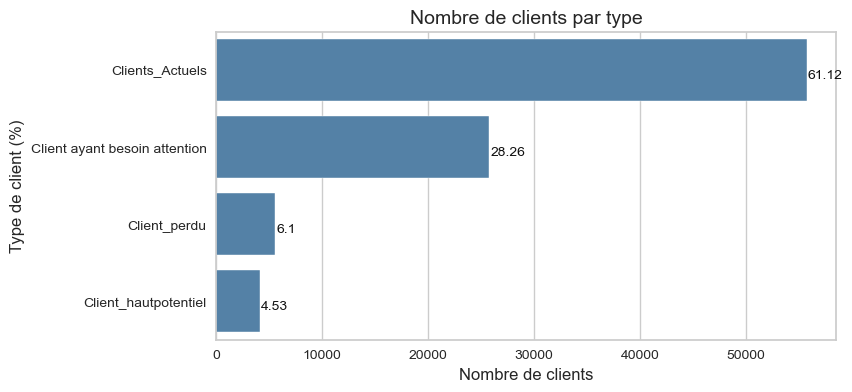

In [31]:
# Répartition des clients dans les différents types
# ---------------------------------------------------------------------
ax1 = plt.gca()

# DataFrame de travail
nb_client = df_segm_rfm['segment_label'].shape[0]
series_type_client = df_segm_rfm['segment_label'].value_counts()
df_visu_type_client = pd.DataFrame(
    {'Type_client': series_type_client.index,
     'Nb_clients': series_type_client.values})
df_visu_type_client['%'] = round(
    (df_visu_type_client['Nb_clients'])*100/nb_client, 2)

# Barplot de la distribution
sns.set_style('white')
sns.barplot(y='Type_client', x='Nb_clients',
            data=df_visu_type_client, color='SteelBlue', ax=ax1)
ax1.set_ylabel('Type de client (%)', fontsize=12)
ax1.set_xlabel('Nombre de clients', fontsize=12)
ax1.set_title('Nombre de clients par type', fontsize=14)
for i, p in enumerate(ax1.patches):
    ax1.text(
        p.get_width() +
        p.get_x() + 100,
        p.get_height() +
        p.get_y() - 0.3,
        df_visu_type_client['%'][i],
        fontsize=10,
        color='k')
plt.gcf().set_size_inches(8, 4)
plt.show()

TRACÉ RADAR

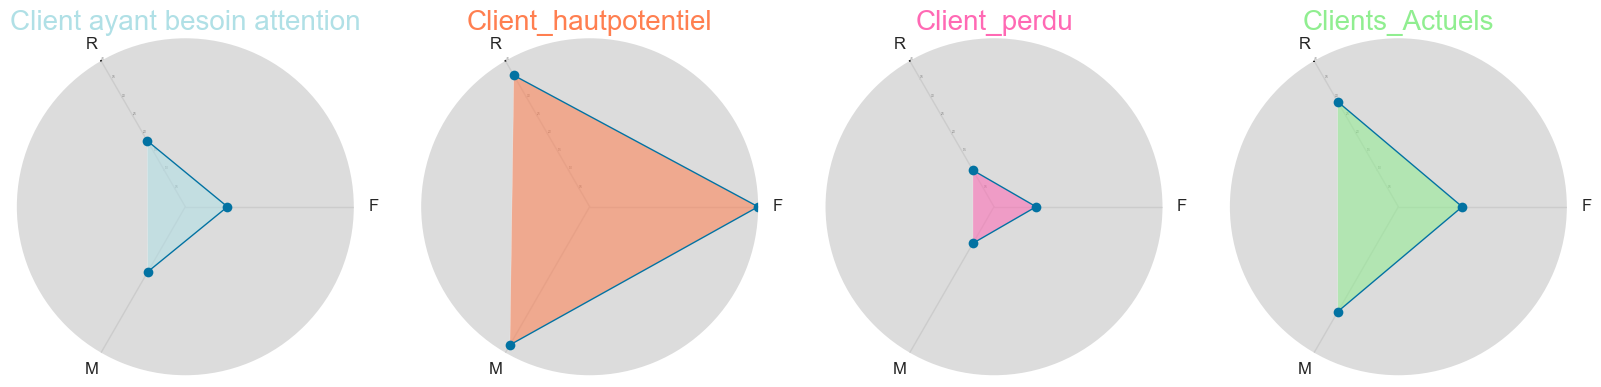

In [34]:
# Radarplot des différents types de client
# ---------------------------------------------------------------------

df_plot = df_segm_rfm.groupby('segment_label')[['R', 'F', 'M',]].mean()
plt.rc('axes', facecolor='Gainsboro')

# number of variable
categories = list(df_plot.columns)

N = len(categories)

# What will be the angle of each axis in the plot? (we divide the plot /
# number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]


fig = plt.figure(1, figsize=(20, 18))

colors = ['PowderBlue', 'Coral', 'HotPink', 'LightGreen']#, 'Cyan',
          #'RoyalBlue', 'Peru', 'MediumPurple', 'Tan', 'Silver',
          #'RoyalBlue', 'DarkOrange']

for i, region in enumerate(df_plot.index):

    ax = fig.add_subplot(3, 4, i+1, polar=True)

    ax.set_theta_offset(2*pi/3)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)

    # Draw one axe per variable + add labels labels yet
    plt.xticks(angles, categories, size=10)
    plt.yticks(color="grey", size=2)
    values = df_plot.iloc[i].values
    ax.plot(angles, values, 'o-', linewidth=1, linestyle='solid')
    ax.fill(angles, values, colors[i], alpha=0.55)
    ax.set_xticks(angles)
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_title(region, size=20, color=colors[i])
    ax.grid(True)
    plt.grid(True)
    plt.ylim(0, 4)

plt.show()

Boxplot

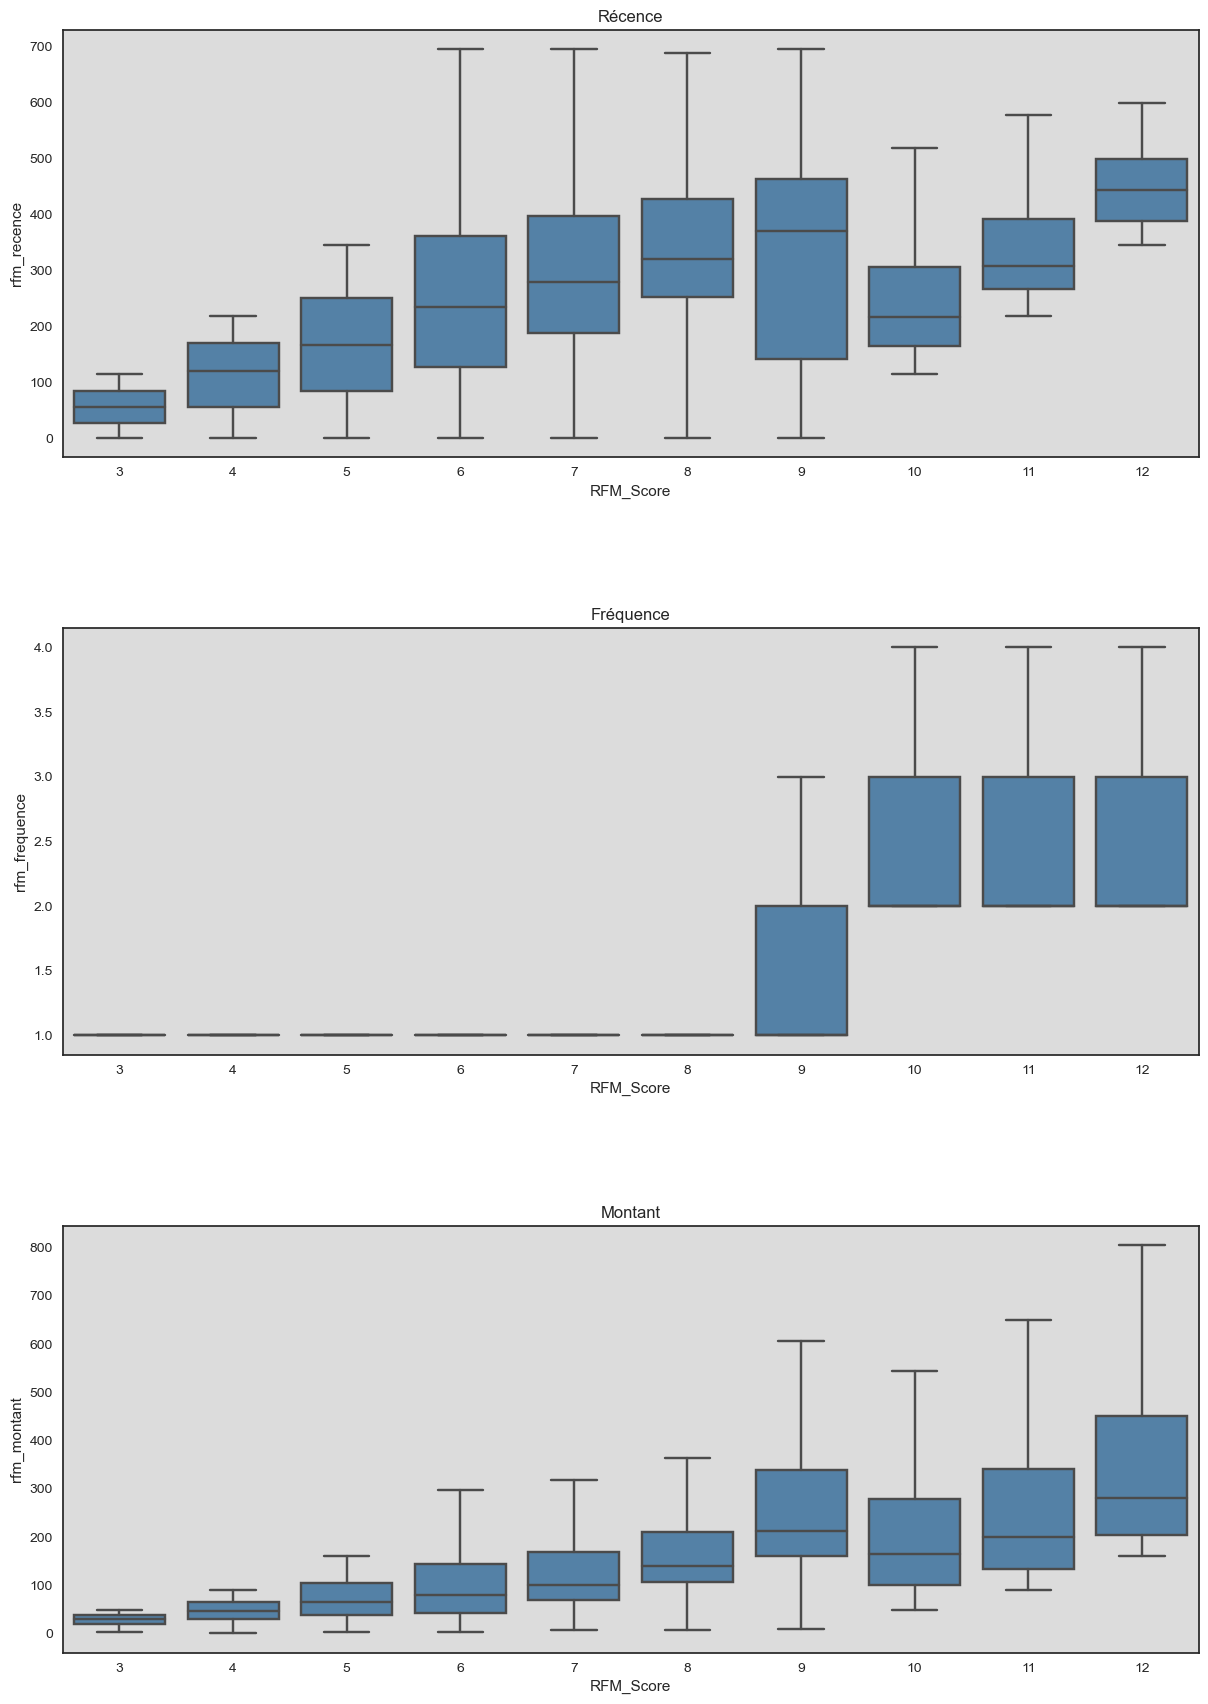

In [35]:
# Boîte à moustache des types de client
# --------------------------------------------------------------------
fig, axs = plt.subplots(3, 1)
fig.subplots_adjust(left=0.08, right=1.5, bottom=0.05,
                    top=3, hspace=0.4, wspace=0.3)

# Boxplot Récence
sns.boxplot(x='RFM_Score', y='rfm_recence', data=df_segm_rfm,
            color='SteelBlue', ax=axs[0],showfliers=False)
axs[0].set_title('Récence')

# Boxplot Fréquence
sns.boxplot(x='RFM_Score', y='rfm_frequence', data=df_segm_rfm,
            color='SteelBlue', ax=axs[1],showfliers=False)
axs[1].set_title('Fréquence')

# Boxplot Montant
sns.boxplot(x='RFM_Score', y='rfm_montant', data=df_segm_rfm,
            color='SteelBlue', ax=axs[2],showfliers=False)
axs[2].set_title('Montant')

plt.show()

# Segmentation RFM - K-Means

In [27]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91223 entries, 0 to 91222
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  91223 non-null  object 
 1   rfm_recence         91223 non-null  int64  
 2   rfm_frequence       91223 non-null  int64  
 3   rfm_montant         91223 non-null  float64
 4   rfm_review          91223 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 3.5+ MB


In [28]:
# Création du datframe de segmentation RFM avec K-Means
df_segm_rfm_kmeans = df_rfm.copy()

In [29]:
df_segm_rfm_kmeans = df_segm_rfm_kmeans.set_index('customer_unique_id')
df_segm_rfm_kmeans.head()

,rfm_recence,rfm_frequence,rfm_montant,rfm_review
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,5.0
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4.0
0000f46a3911fa3c0805444483337064,537,1,69.00,3.0
0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,4.0
0004aac84e0df4da2b147fca70cf8255,288,1,180.00,5.0


In [30]:
# Valeurs négatives ?
df_segm_rfm_kmeans[['rfm_recence', 'rfm_frequence', 'rfm_montant','rfm_review']] \
    .describe()

,rfm_recence,rfm_frequence,rfm_montant,rfm_review
count,91223.00000,91223.00000,91223.00000,91223.00000
mean,237.08617,1.23765,148.35829,5.05248
std,152.57928,0.84469,243.88478,3.73670
min,1.00000,1.00000,0.85000,1.00000
25%,114.00000,1.00000,48.90000,4.00000
50%,218.00000,1.00000,89.90000,5.00000
75%,345.00000,1.00000,159.90000,5.00000
max,695.00000,75.00000,13440.00000,375.00000


<Figure size 1000x500 with 0 Axes>

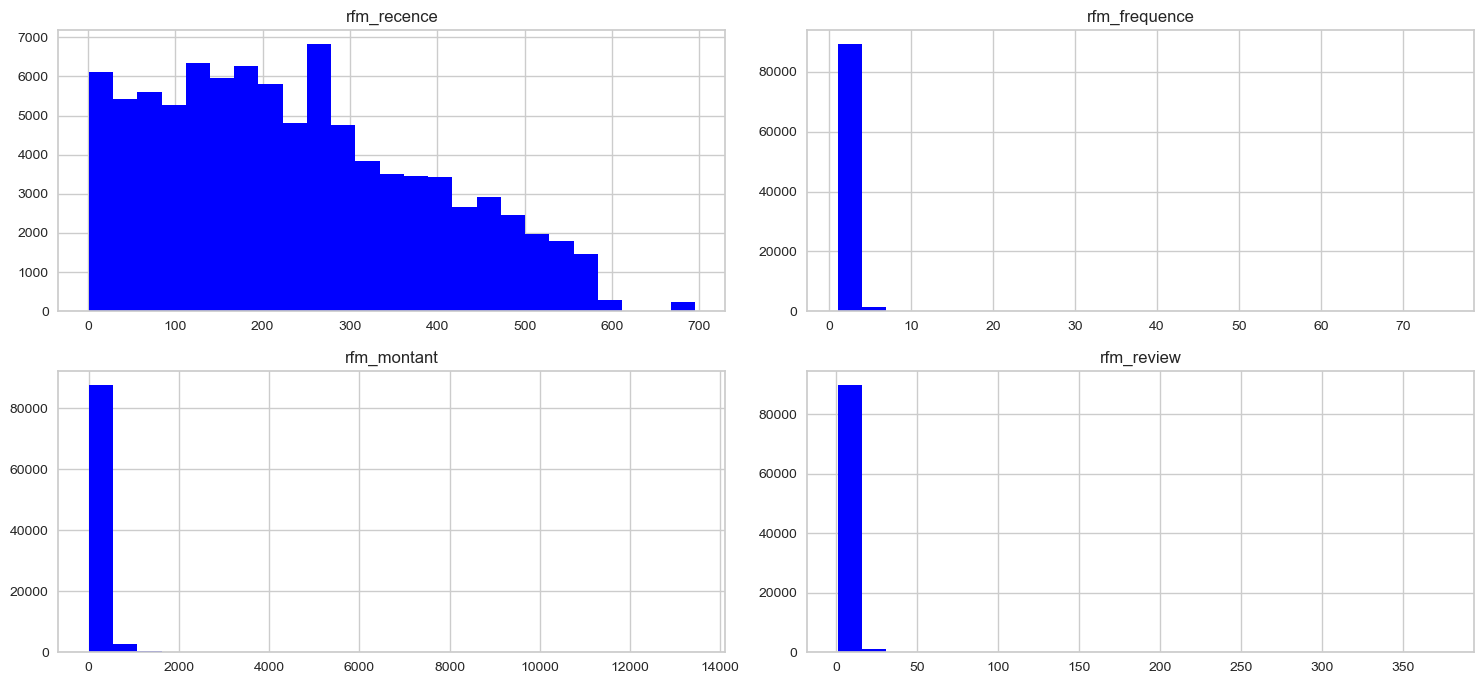

In [31]:
plt.figure(figsize = (10,5))
df_segm_rfm_kmeans.hist(figsize = (15,7), color = "blue", bins = 25)
plt.tight_layout()

In [32]:
# Transformer les valeurs en logarithme pour que chaque variable aie
# le même poids
cols_preproc = ['rfm_recence', 'rfm_frequence', 'rfm_montant','rfm_review']
df_rfm_log = df_segm_rfm_kmeans[cols_preproc].apply(np.log, axis=1)


<Figure size 1000x500 with 0 Axes>

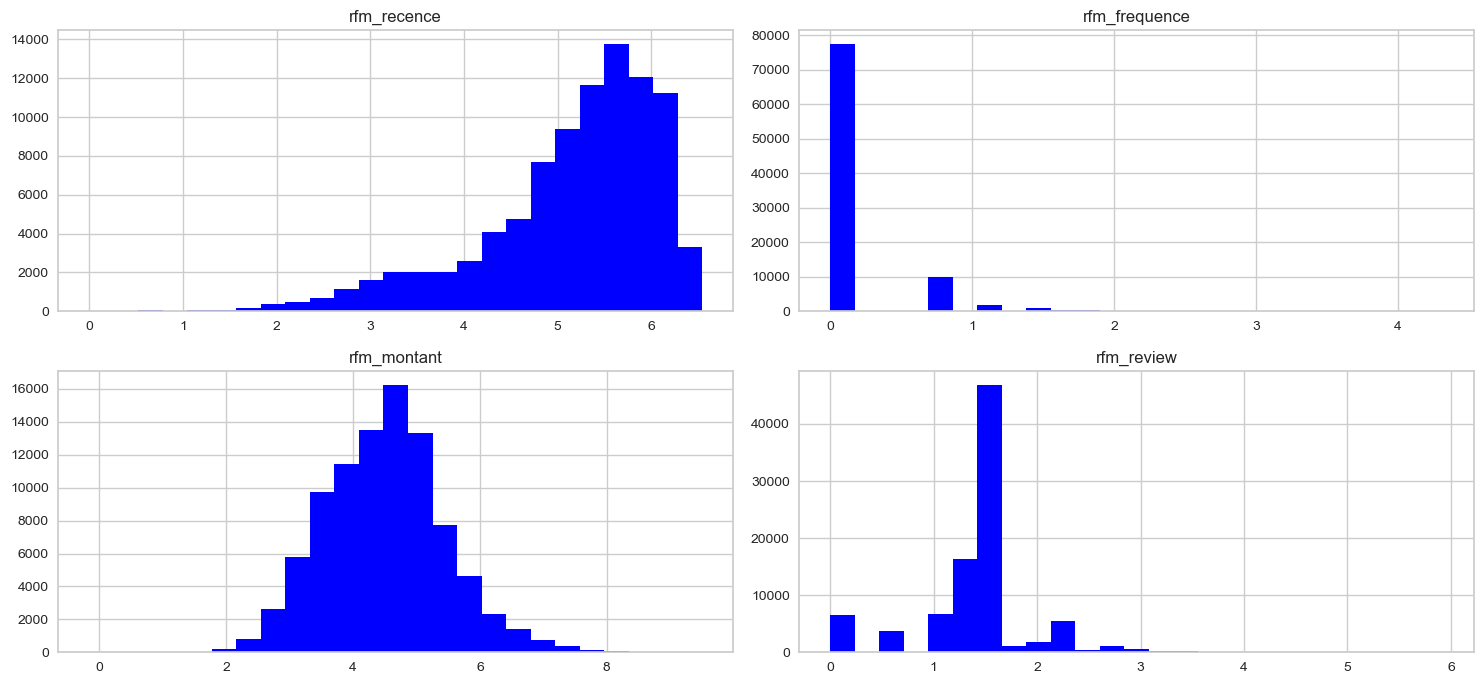

In [33]:
plt.figure(figsize = (10,5))
df_rfm_log.hist(figsize = (15,7), color = "blue", bins = 25)
plt.tight_layout()

In [34]:
# Standardisation StandardScaler
# -----------------------------------------------------------------------
scaler = StandardScaler()
df_rfm_scaled = scaler.fit_transform(df_rfm_log)
# Dataframe
df_rfm_scaled = pd.DataFrame(df_rfm_scaled, index=df_segm_rfm_kmeans.index,
                             columns=df_rfm_log.columns)

In [35]:
df_rfm_scaled[['rfm_recence', 'rfm_frequence', 'rfm_montant','rfm_review']] \
    .describe()

,rfm_recence,rfm_frequence,rfm_montant,rfm_review
count,9.12230e+04,9.12230e+04,9.12230e+04,9.12230e+04
mean,5.66694e-16,-4.47872e-18,-2.74799e-16,-2.43019e-17
std,1.00001e+00,1.00001e+00,1.00001e+00,1.00001e+00
min,-5.40182e+00,-3.86972e-01,-4.89783e+00,-2.62754e+00
25%,-4.33740e-01,-3.86972e-01,-6.36131e-01,-1.48764e-01
50%,2.46296e-01,-3.86972e-01,4.25588e-03,2.50229e-01
75%,7.27821e-01,-3.86972e-01,6.09864e-01,2.50229e-01
max,1.46248e+00,1.24053e+01,5.27030e+00,7.97015e+00


<Figure size 1000x500 with 0 Axes>

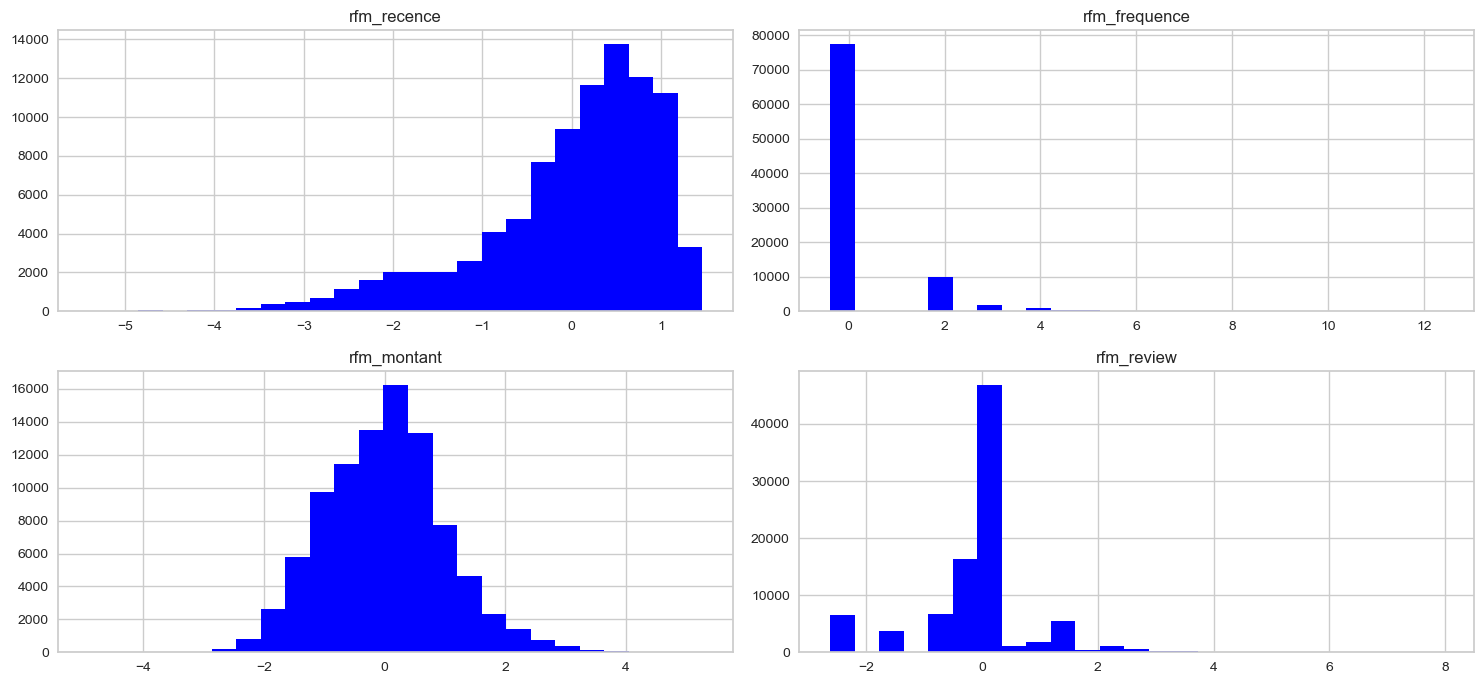

In [36]:
plt.figure(figsize = (10,5))
df_rfm_scaled.hist(figsize = (15,7), color = "blue", bins = 25)
plt.tight_layout()

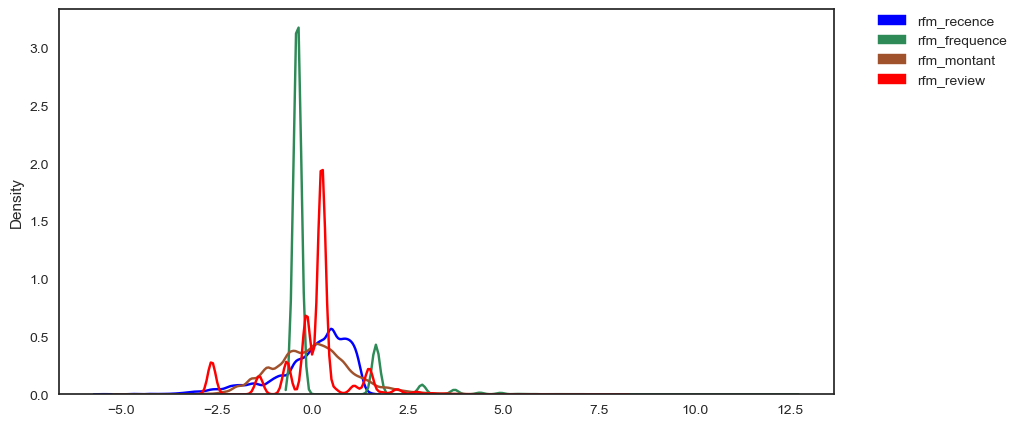

In [50]:
 plt.figure(figsize=(10, 5))
axes = plt.axes()

label_patches = []
 colors = ['Blue', 'SeaGreen', 'Sienna', 'red']

i = 0
for col in df_rfm_scaled.columns:
        label = col
        sns.kdeplot(df_rfm_scaled[col], color=colors[i])
        label_patch = mpatches.Patch(
            color=colors[i],
            label=label)
        label_patches.append(label_patch)
        i += 1
plt.xlabel('')
plt.legend(
        handles=label_patches,
        bbox_to_anchor=(
            1.05,
            1),
        loc=2,
        borderaxespad=0.,
        facecolor='white')
plt.grid(False)
axes.set_facecolor('white')

plt.show()

# en utilisant une fonction

In [51]:
def plot_graph(df_work):
    """Graph densité pour 1 ou plusieurs colonne d'un dataframe
       @param in : df_work dataframe obligatoire
       @param out : none
    """

    plt.figure(figsize=(10, 5))
    axes = plt.axes()

    label_patches = []
    colors = ['Blue', 'SeaGreen', 'Sienna', 'red', 'Purple']

    i = 0
    for col in df_work.columns:
        label = col
        sns.kdeplot(df_work[col], color=colors[i])
        label_patch = mpatches.Patch(
            color=colors[i],
            label=label)
        label_patches.append(label_patch)
        i += 1
    plt.xlabel('')
    plt.legend(
        handles=label_patches,
        bbox_to_anchor=(
            1.05,
            1),
        loc=2,
        borderaxespad=0.,
        facecolor='white')
    plt.grid(False)
    axes.set_facecolor('white')

    plt.show()

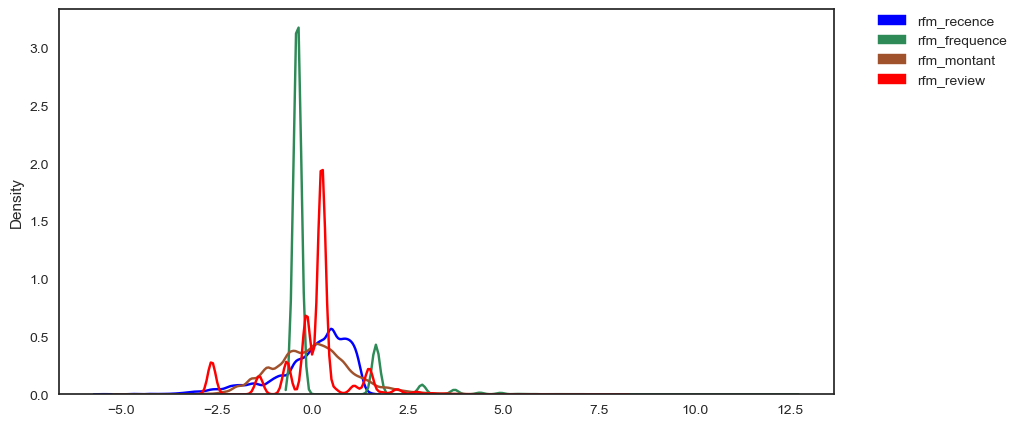

In [44]:
# Standardisation StandardScaler
# -----------------------------------------------------------------------
scaler = StandardScaler()
df_rfm_scaled = scaler.fit_transform(df_rfm_log)
# Dataframe
df_rfm_scaled = pd.DataFrame(df_rfm_scaled, index=df_segm_rfm_kmeans.index,
                             columns=df_rfm_log.columns)
# Visualisation  faire introduire le code
plot_graph(df_rfm_scaled)

In [37]:
df_rfm_scaled

,rfm_recence,rfm_frequence,rfm_montant,rfm_review
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,-0.45231,-0.38697,0.39134,0.25023
0000b849f77a49e4a4ce2b2a4ca5be3f,-0.42458,-0.38697,-1.63587,-0.14876
0000f46a3911fa3c0805444483337064,1.19194,-0.38697,-0.27401,-0.66316
0000f6ccb0745a6a4b88665a16c9f078,0.65219,-0.38697,-1.30086,-0.14876
0004aac84e0df4da2b147fca70cf8255,0.53840,-0.38697,0.73439,0.25023
...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,0.99952,1.66676,3.01219,1.48962
fffea47cd6d3cc0a88bd621562a9d061,0.43915,-0.38697,-0.33859,-0.14876
ffff371b4d645b6ecea244b27531430a,1.25081,-0.38697,0.00426,0.25023


# Recherche du meilleur hyper-paramètre k



In [38]:
# Méthode Elbow :Avec données standardisées avec StandardScaler

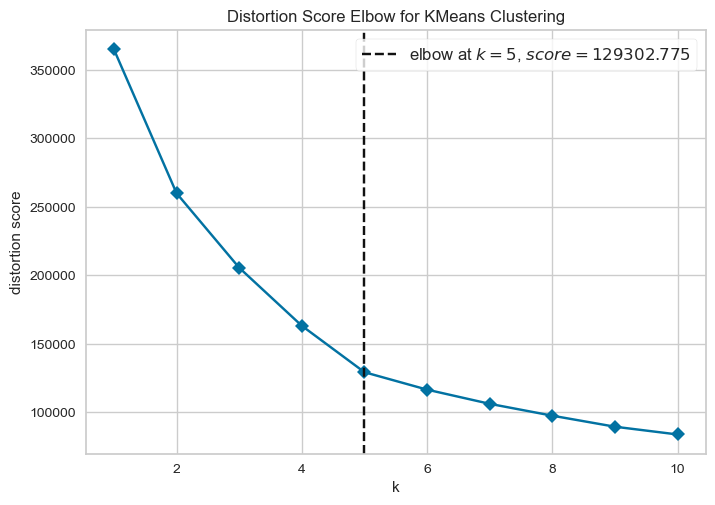

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [39]:
# Instanciation du modèle
model = KMeans()

# Hyperparamètre k entre 1 et 11
# métrique = distortion ( calcule la somme des distances au carré entre
# chaque point et le centre qui lui est attribué)
visualizer = KElbowVisualizer(model, k=(1, 11), timings=False)

# Entraîne le modèle
visualizer.fit(df_rfm_scaled)
visualizer.show()

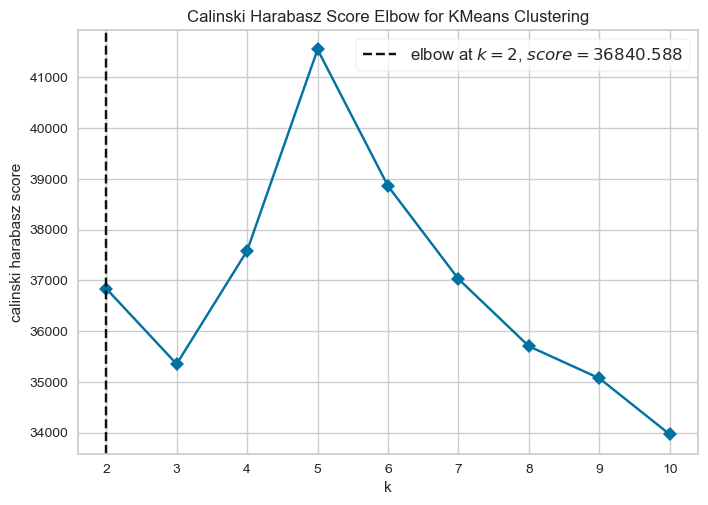

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [40]:
# Instanciation du modèle
model = KMeans()

# Hyperparamètre k entre 1 et 11
# métrique = calinski_harabasz (calcule le rapport de dispersion entre
# et au sein des clusters)
visualizer = KElbowVisualizer(model, k=(2, 11),
                              metric='calinski_harabasz', timings=False)

# Entraîne le modèle
visualizer.fit(df_rfm_scaled)
visualizer.show()

In [52]:
#Avec données standardisées avec StandardScaler

# Clustering avec k=5 comme meilleur hyperparamètre
clus = KMeans(n_clusters=5, init='k-means++', max_iter=300)
clus.fit(df_rfm_scaled)

In [43]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(df_rfm_scaled)
    
    # Calculer les étiquettes des clusters et le coefficient de silhouette
labels = kmeans.labels_
silhouette_avg = silhouette_score(df_rfm_scaled, labels)


In [44]:
silhouette_avg

0.3299103688204525

In [45]:
# AJout du groupe de cluster au jeu de données
df_segm_rfm['K_Cluster'] =kmeans.labels_
df_segm_rfm_kmeans['K_Cluster'] = kmeans.labels_
cluster_labels = kmeans.labels_

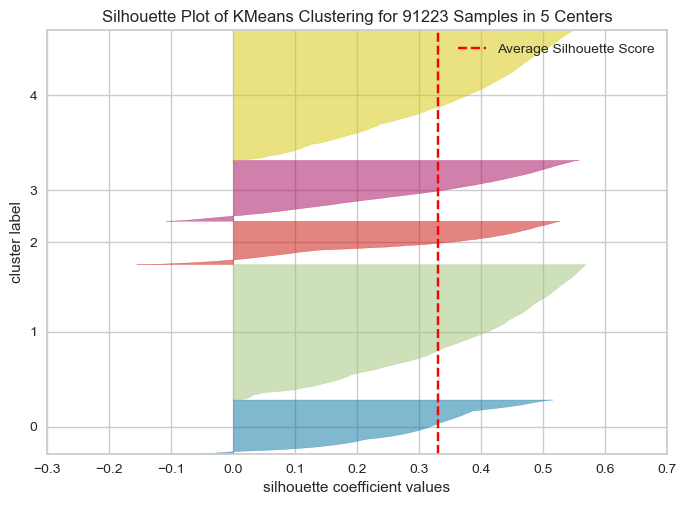

In [32]:
from yellowbrick.cluster import SilhouetteVisualizer
model = KMeans(n_clusters=5, random_state=42)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(df_rfm_scaled)
visualizer.show()
plt.show()

In [34]:
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(df_rfm_scaled)
    
    # Calculer les étiquettes des clusters et le coefficient de silhouette
labels = kmeans.labels_
silhouette_avg = silhouette_score(df_rfm_scaled, labels)


In [35]:
silhouette_avg

0.333154098012319

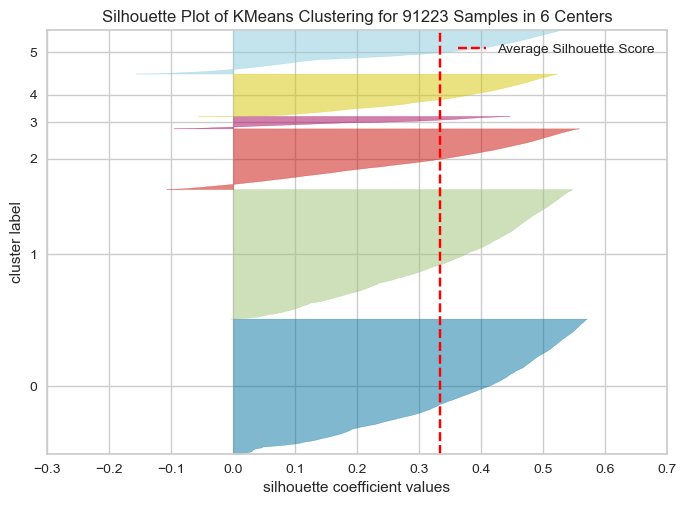

In [36]:
from yellowbrick.cluster import SilhouetteVisualizer
model = KMeans(n_clusters=6, random_state=42)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(df_rfm_scaled)
visualizer.show()
plt.show()

# Choix kmeans avec standard scaler: clusters=5

In [46]:
# Constitution du dataframe de travail données StandardScaler
# --------------------------------------------------------------------
# Ajout de la colonne de cluster
df_rfm['K_Cluster'] = kmeans.labels_



In [47]:
df_rfm.head()

,customer_unique_id,rfm_recence,rfm_frequence,rfm_montant,rfm_review,K_Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,5.0,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4.0,1
2,0000f46a3911fa3c0805444483337064,537,1,69.00,3.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,4.0,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,5.0,4


In [48]:
df_rfm

,customer_unique_id,rfm_recence,rfm_frequence,rfm_montant,rfm_review,K_Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,5.0,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4.0,1
2,0000f46a3911fa3c0805444483337064,537,1,69.00,3.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,4.0,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,5.0,4
...,...,...,...,...,...,...
91218,fffcf5a5ff07b0908bd4e2dbc735a684,447,2,1570.00,10.0,0
91219,fffea47cd6d3cc0a88bd621562a9d061,262,1,64.89,4.0,1
91220,ffff371b4d645b6ecea244b27531430a,568,1,89.90,5.0,4
91221,ffff5962728ec6157033ef9805bacc48,119,1,115.00,5.0,4


In [49]:
# Sélectionnez les colonnes à normaliser
cols_to_normalize = ['rfm_recence', 'rfm_frequence', 'rfm_montant', 'rfm_review']

# Initialisez le MinMaxScaler
scaler = MinMaxScaler()

# Appliquez le scaler sur les colonnes sélectionnées et remplacez-les dans le DataFrame
df_rfm[cols_to_normalize] = scaler.fit_transform(df_rfm[cols_to_normalize])

In [50]:
df_rfm

,customer_unique_id,rfm_recence,rfm_frequence,rfm_montant,rfm_review,K_Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,0.15994,0.00000,0.00960,0.01070,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.16427,0.00000,0.00134,0.00802,1
2,0000f46a3911fa3c0805444483337064,0.77233,0.00000,0.00507,0.00535,1
3,0000f6ccb0745a6a4b88665a16c9f078,0.46110,0.00000,0.00187,0.00802,1
4,0004aac84e0df4da2b147fca70cf8255,0.41354,0.00000,0.01333,0.01070,4
...,...,...,...,...,...,...
91218,fffcf5a5ff07b0908bd4e2dbc735a684,0.64265,0.01351,0.11676,0.02406,0
91219,fffea47cd6d3cc0a88bd621562a9d061,0.37608,0.00000,0.00477,0.00802,1
91220,ffff371b4d645b6ecea244b27531430a,0.81700,0.00000,0.00663,0.01070,4
91221,ffff5962728ec6157033ef9805bacc48,0.17003,0.00000,0.00849,0.01070,4


In [51]:
df_rfm['K_Cluster'].value_counts()

1    29177
4    27930
3    13112
0    11677
2     9327
Name: K_Cluster, dtype: int64

In [52]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91223 entries, 0 to 91222
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  91223 non-null  object 
 1   rfm_recence         91223 non-null  float64
 2   rfm_frequence       91223 non-null  float64
 3   rfm_montant         91223 non-null  float64
 4   rfm_review          91223 non-null  float64
 5   K_Cluster           91223 non-null  int32  
dtypes: float64(4), int32(1), object(1)
memory usage: 3.8+ MB


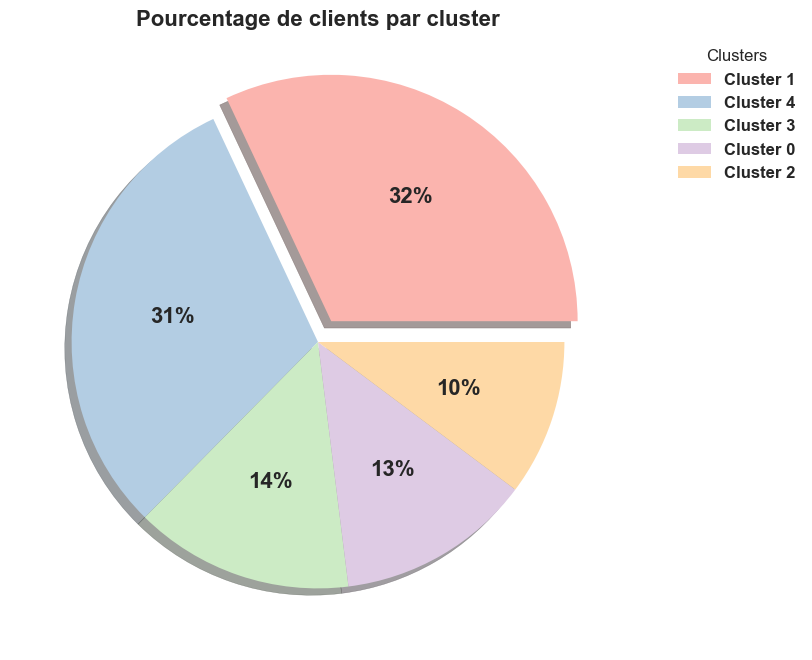

In [53]:
# Configuration de la figure
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(aspect='equal'))

# Configuration pour 'explode' (faire ressortir un secteur)
explode = (0.1, 0, 0,0,0)  # Ajustez en fonction du nombre de clusters

# Calcul des valeurs pour le diagramme
p = df_rfm['K_Cluster'].value_counts()

# Générer des couleurs automatiquement en fonction du nombre de clusters
colors = plt.cm.Pastel1(range(len(p)))

# Création du diagramme en secteurs
p.plot(kind="pie", labels=None, startangle=0, explode=explode, autopct='%1.0f%%', 
       pctdistance=0.6, shadow=True, textprops={'weight': 'bold', 'fontsize': 16}, 
       colors=colors, ax=ax)

# Création des étiquettes de légende basées sur les clusters présents
legend_labels = [f'Cluster {i}' for i in p.index]

# Ajout de la légende
ax.legend(legend_labels, title="Clusters", loc='best', shadow=True, 
          prop={'weight': 'bold', 'size': 12}, bbox_to_anchor=(0.8, 0, 0.5, 1))

# Titre du diagramme
plt.title('Pourcentage de clients par cluster', fontweight='bold', size=16)

# Suppression du label de l'axe des y
plt.ylabel("")

# Affichage du diagramme
plt.show()

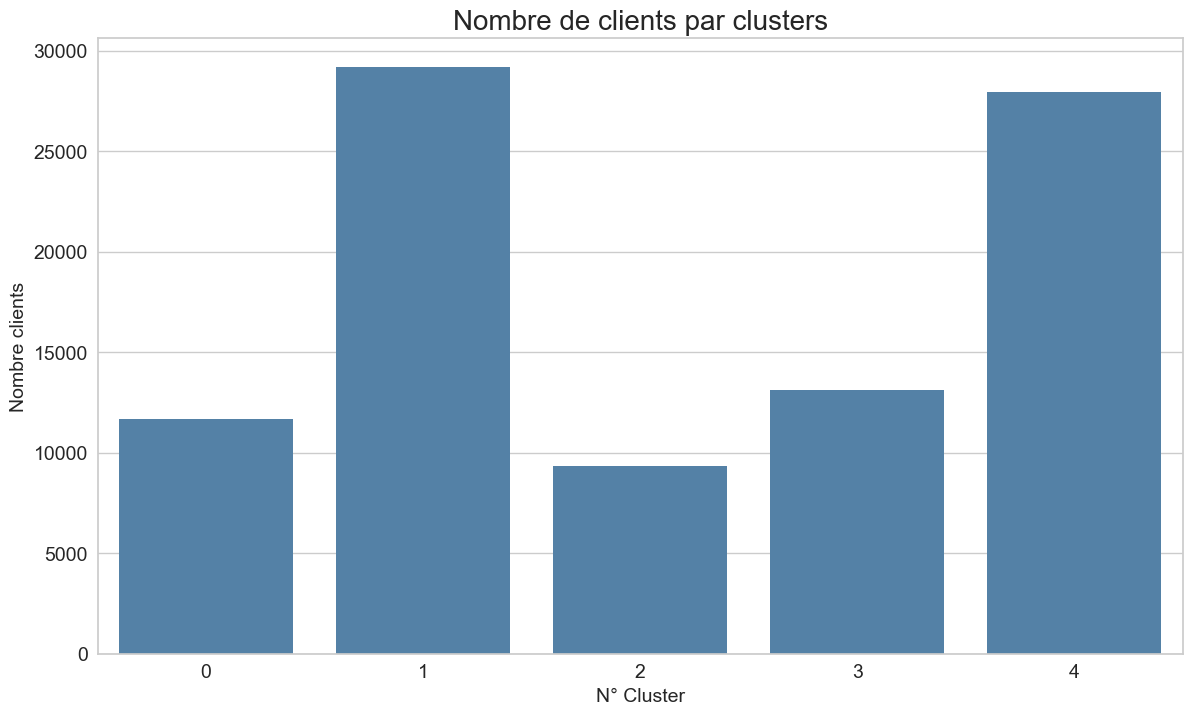

In [57]:
cluster_kmeans = df_rfm['K_Cluster'].value_counts(sort=False)

# Countplot
plt.figure(figsize=(14, 8))
sns.barplot(x=cluster_kmeans.index, y=cluster_kmeans.values,
            color='SteelBlue')

plt.title('Nombre de clients par clusters',
          fontsize=20)
plt.ylabel('Nombre clients', fontsize=14)
plt.xlabel('N° Cluster', fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [58]:
df_rfm_km=df_rfm[['rfm_recence', 'rfm_frequence', 'rfm_montant', 'rfm_review','K_Cluster']]

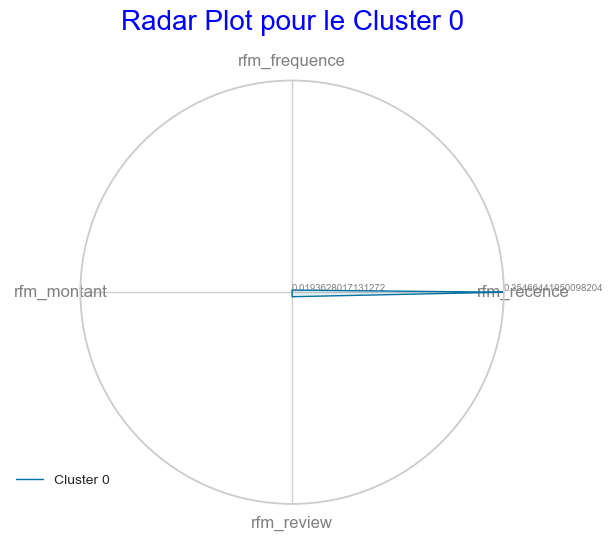

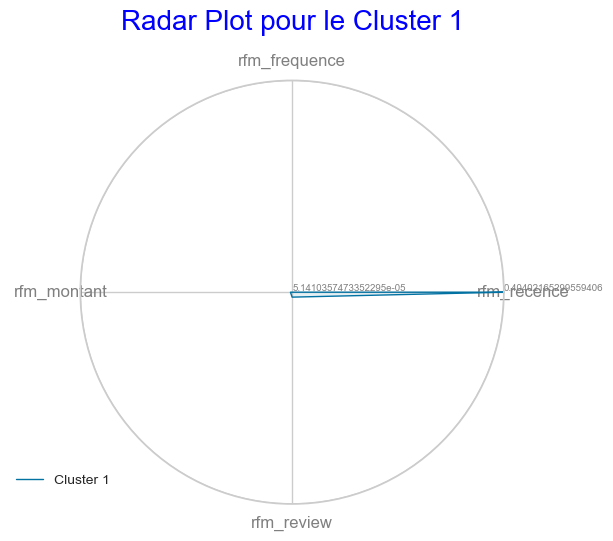

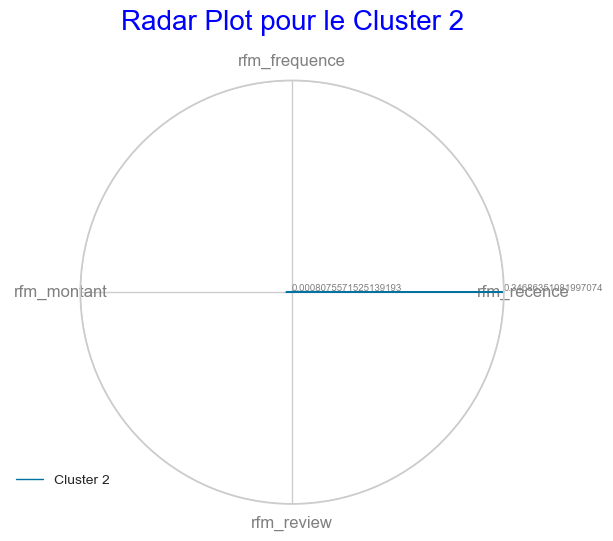

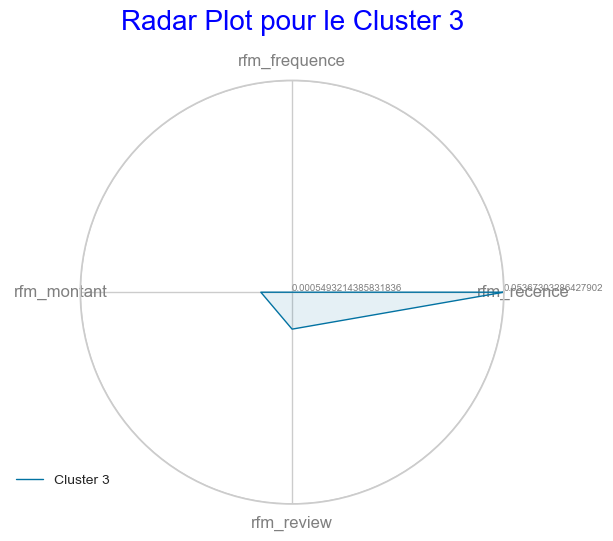

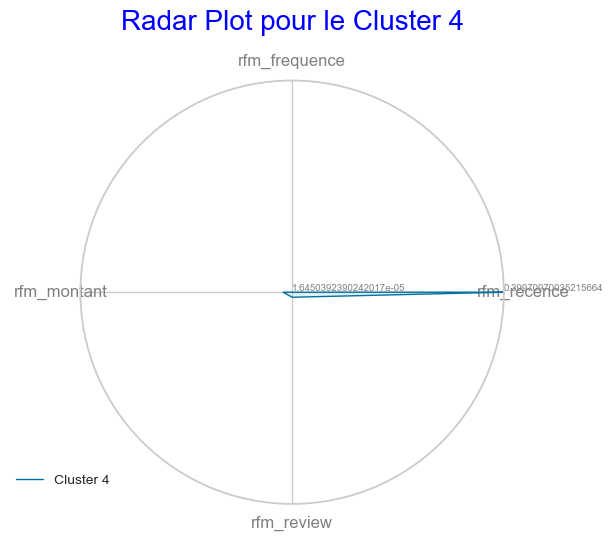

In [59]:
from math import pi

# Étape 1: Calcul des moyennes pour chaque cluster
# Remplacer `df_rfm` par votre DataFrame
cluster_means = df_rfm_km.groupby('K_Cluster').mean()

# Étape 2: Création des diagrammes radar pour chaque cluster
# Définition des catégories (variables rfm)
categories = ['rfm_recence', 'rfm_frequence', 'rfm_montant', 'rfm_review']
N = len(categories)

# Création d'une boucle pour générer un diagramme radar pour chaque cluster
for cluster in cluster_means.index:
    values = cluster_means.loc[cluster, categories].tolist()
    values += values[:1]  # pour fermer le cercle du diagramme radar

    # Calcul des angles pour chaque axe dans le radar
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Initialisation du diagramme radar
    ax = plt.subplot(111, polar=True)

    # Premier axe en haut
    plt.xticks(angles[:-1], categories, color='grey', size=12)

    # Dessin des lignes y
    ax.set_rlabel_position(0)
    plt.yticks([min(values), max(values)], [str(min(values)), str(max(values))], color="grey", size=7)
    plt.ylim(min(values), max(values))

    # Plot des données
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {cluster}')

    # Remplissage de l'aire
    ax.fill(angles, values, 'b', alpha=0.1)

    # Ajout d'un titre
    plt.title(f'Radar Plot pour le Cluster {cluster}', size=20, color='blue', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

    # Affichage du diagramme
    plt.show()



In [60]:
df_rfm_km1=df_rfm_km.groupby('K_Cluster').mean()

In [61]:
df_rfm_km1

,rfm_recence,rfm_frequence,rfm_montant,rfm_review
K_Cluster,,,,
0,0.35466,0.02273,0.01936,0.02652
1,0.40402,0.00005,0.00316,0.00946
2,0.34686,0.00197,0.01085,0.00081
3,0.05367,0.00055,0.00839,0.00982
4,0.39971,0.00002,0.01688,0.00954


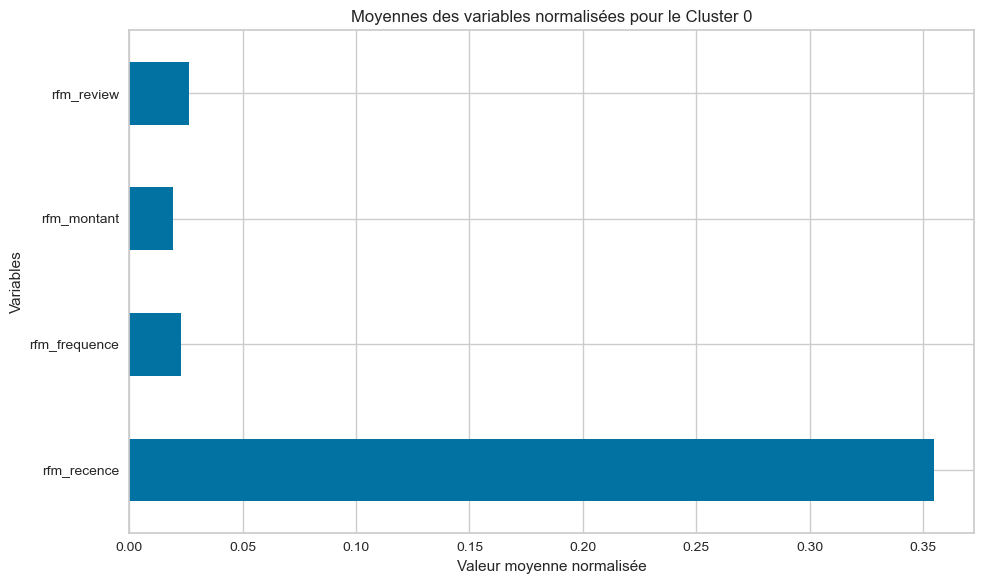

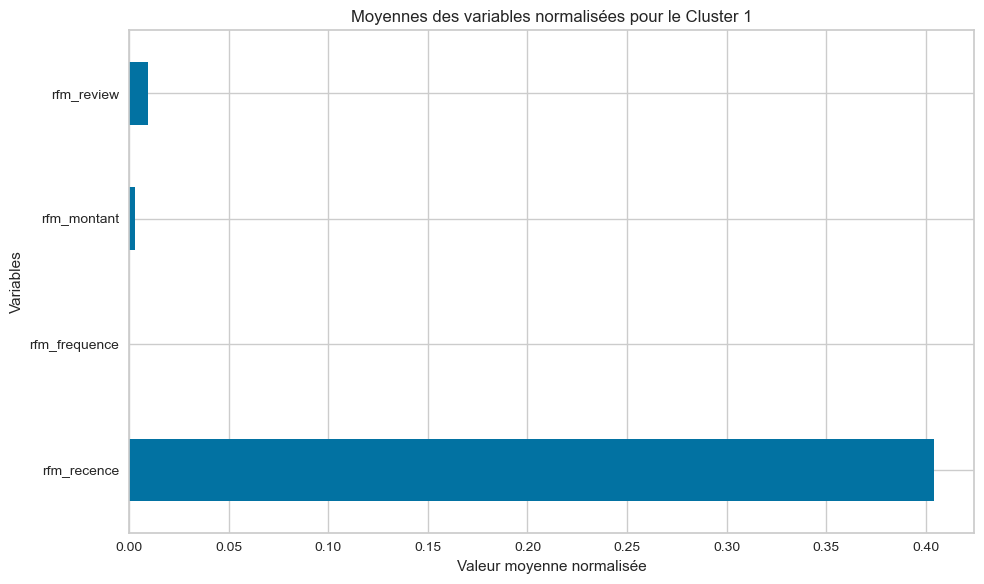

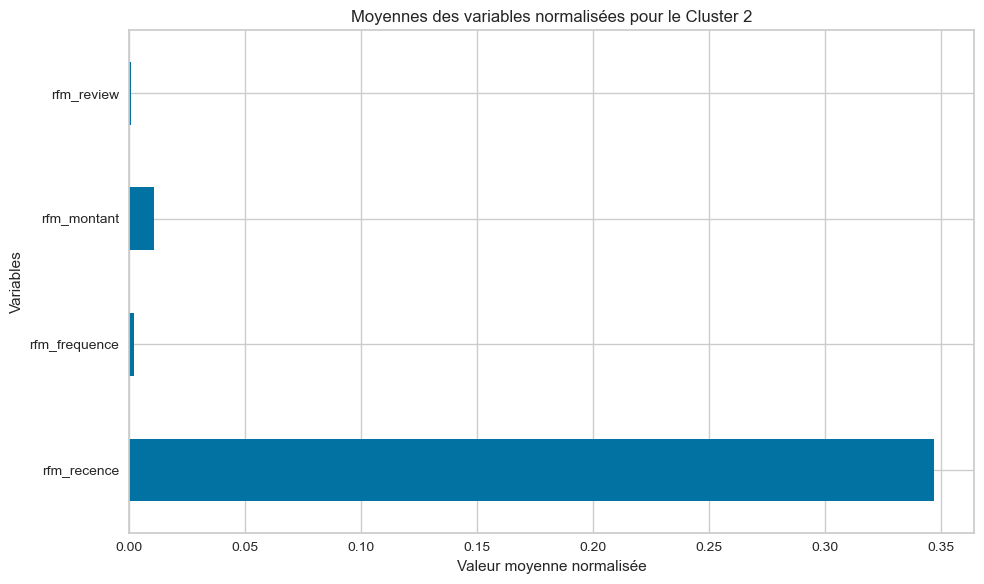

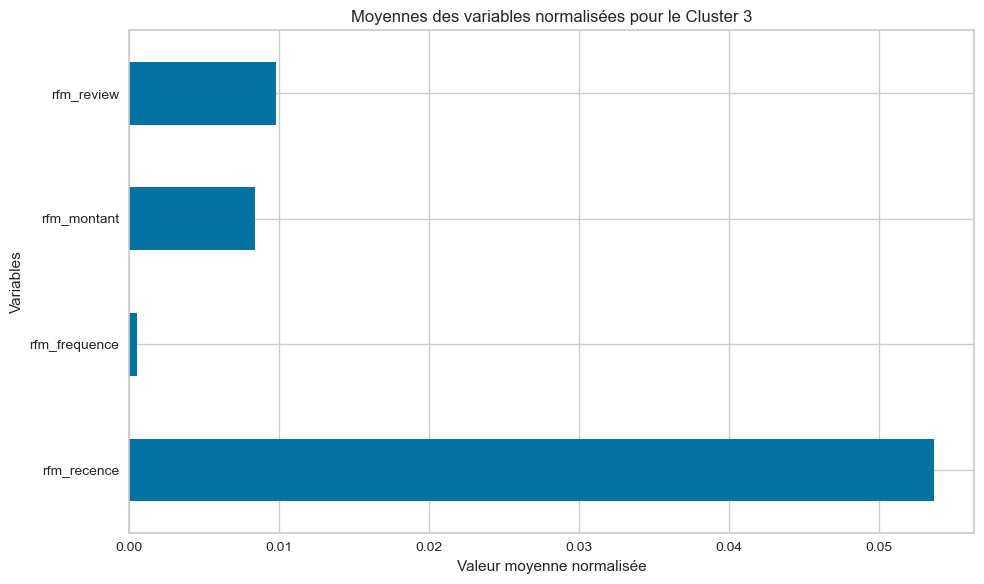

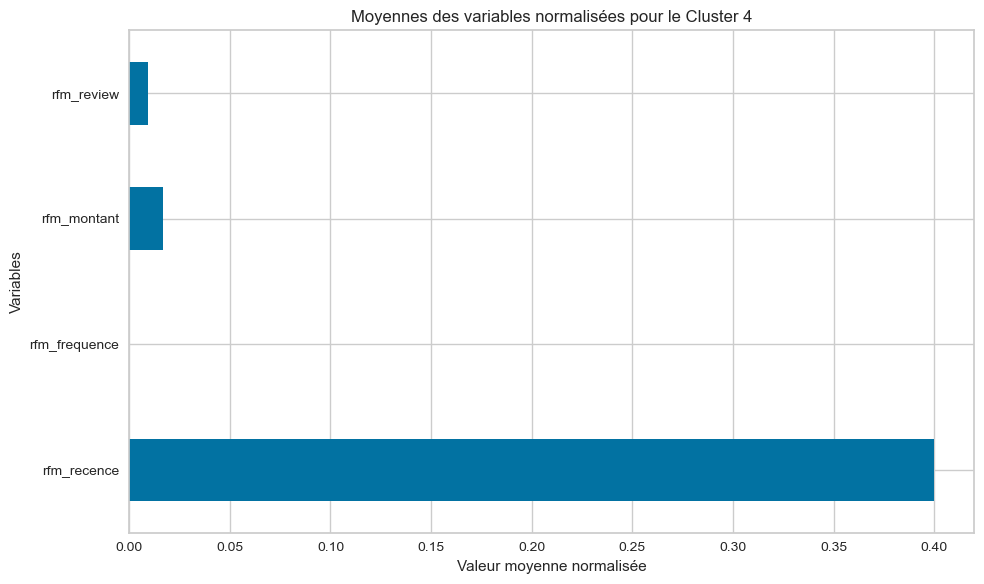

In [62]:
# Étape 1 : Normalisation des données (à l'exception de la colonne 'K_cluster')
#scaler = MinMaxScaler()
# Remplacer 'df_rfm' par votre DataFrame
#scaled_features = scaler.fit_transform(df_rfm_km.drop('K_Cluster', axis=1))
#df_rfm_scaled = pd.DataFrame(scaled_features, columns=df_rfm_km.columns[:-1])
#df_rfm_scaled['K_Cluster'] = df_rfm_km['K_Cluster'].values

# Étape 2 : Calcul des moyennes pour chaque cluster
cluster_means = df_rfm_km.groupby('K_Cluster').mean()

# Étape 3 : Tracer un graphique en barres horizontales pour chaque cluster
for cluster in cluster_means.index:
    plt.figure(figsize=(10, 6))
    ax = cluster_means.loc[cluster].plot(kind='barh')
    ax.set_title(f'Moyennes des variables normalisées pour le Cluster {cluster}')
    ax.set_xlabel('Valeur moyenne normalisée')
    ax.set_ylabel('Variables')
    plt.tight_layout()
    plt.show()

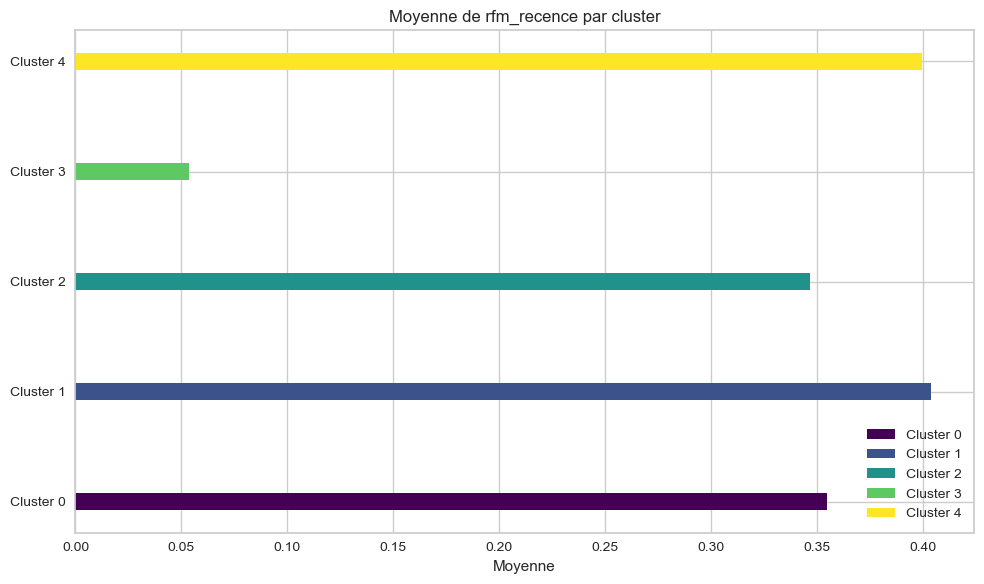

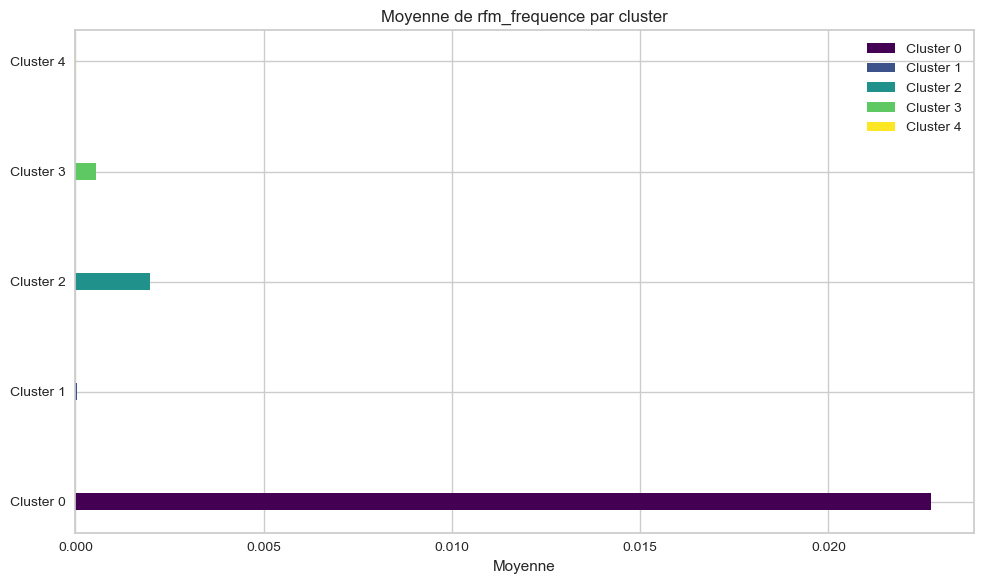

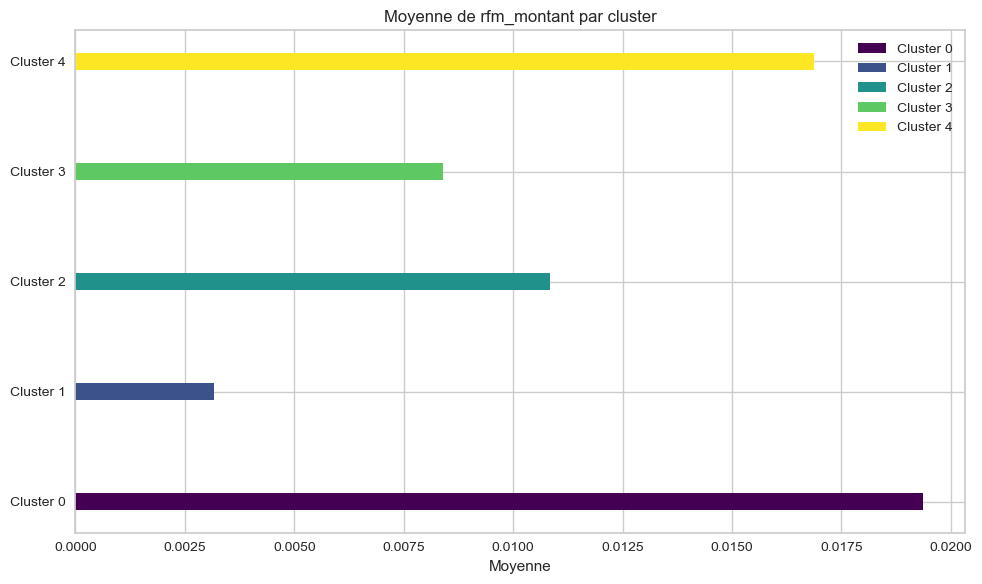

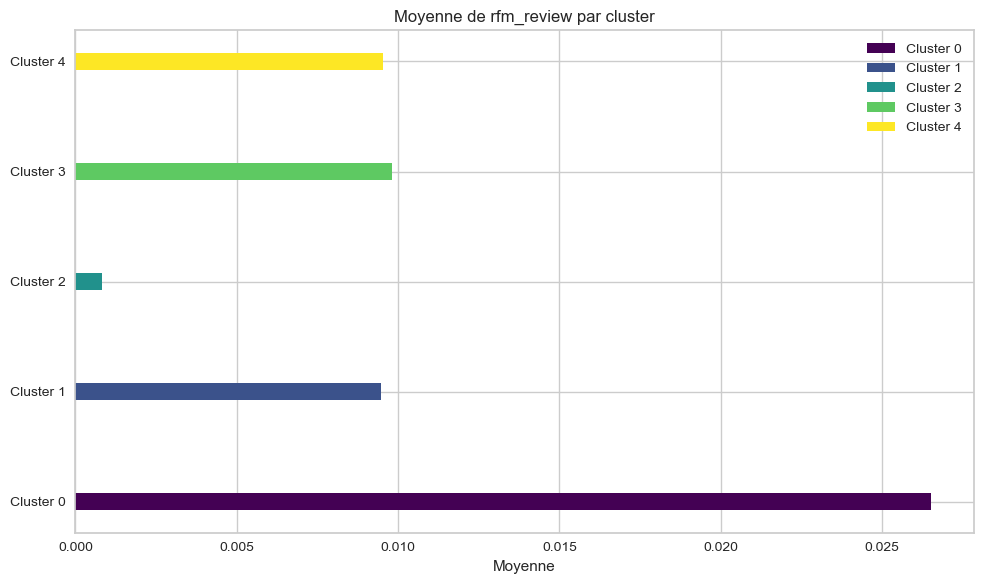

In [63]:


# Calcul des moyennes pour chaque cluster
cluster_means = df_rfm_km.groupby('K_Cluster').mean()

# Liste des variables à tracer
variables = ['rfm_recence', 'rfm_frequence', 'rfm_montant', 'rfm_review']

# Configuration de la visualisation
num_clusters = cluster_means.shape[0]
bar_width = 0.15  # Largeur des barres
colors = plt.cm.viridis(np.linspace(0, 1, num_clusters))  # Génération de couleurs

# Tracer un graphique en barres pour chaque variable
for variable in variables:
    plt.figure(figsize=(10, 6))  # Création d'une nouvelle figure
    
    # Tracé des barres pour chaque cluster
    for i, cluster in enumerate(cluster_means.index):
        plt.barh(i, cluster_means.loc[cluster, variable], bar_width, color=colors[i], label=f'Cluster {cluster}')
    
    plt.xlabel('Moyenne')
    plt.title(f'Moyenne de {variable} par cluster')
    plt.yticks([i for i in range(num_clusters)], [f'Cluster {i}' for i in range(num_clusters)])
    
    # Ajout de la légende
    plt.legend()

    plt.tight_layout()
    plt.show()

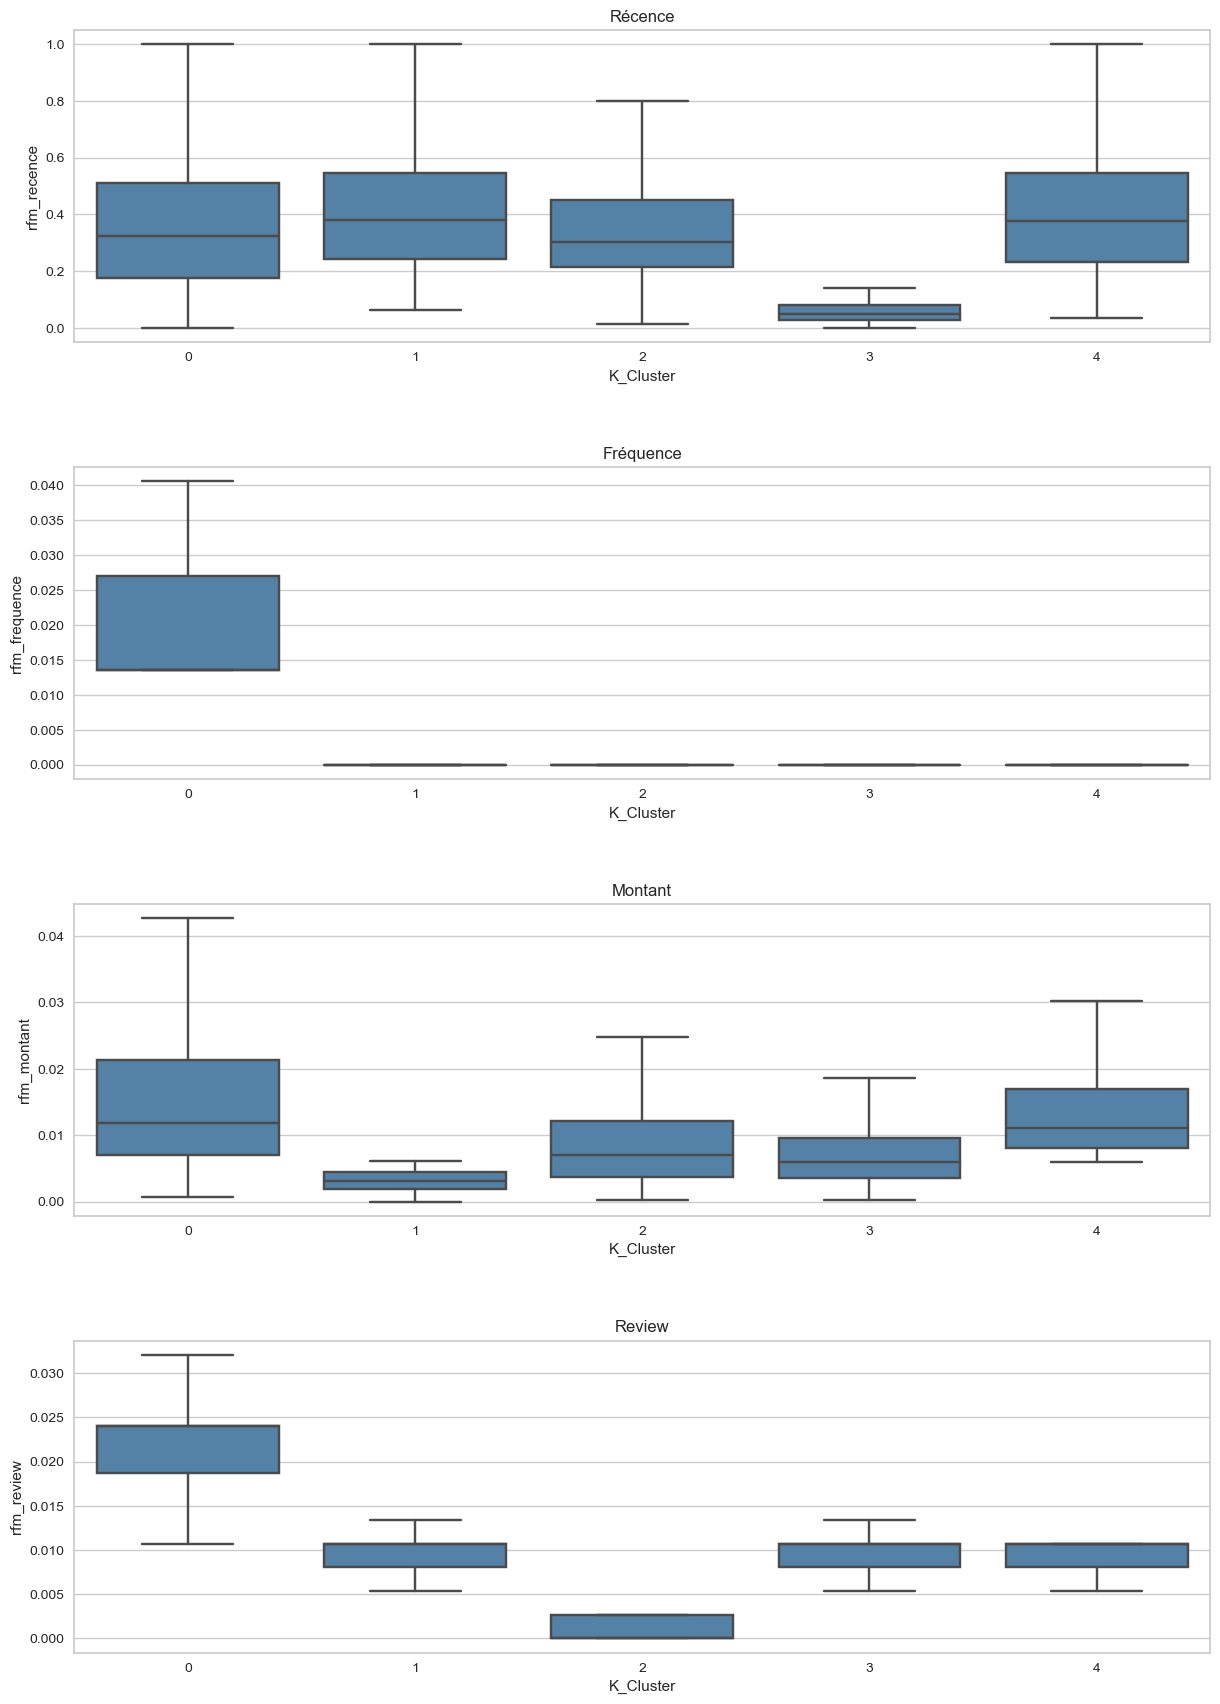

In [64]:
# Boîte à moustache des types de client
# --------------------------------------------------------------------
fig, axs = plt.subplots(4, 1)
fig.subplots_adjust(left=0.08, right=1.5, bottom=0.05,
                    top=3, hspace=0.4, wspace=0.3)

# Boxplot Récence
sns.boxplot(x='K_Cluster', y='rfm_recence', data=df_rfm_km,
            color='SteelBlue', ax=axs[0],showfliers=False)
axs[0].set_title('Récence')

# Boxplot Fréquence
sns.boxplot(x='K_Cluster', y='rfm_frequence', data=df_rfm_km,
            color='SteelBlue', ax=axs[1],showfliers=False)
axs[1].set_title('Fréquence')

# Boxplot Montant
sns.boxplot(x='K_Cluster', y='rfm_montant', data=df_rfm_km,
            color='SteelBlue', ax=axs[2],showfliers=False)
axs[2].set_title('Montant')
# Boxplot Review
sns.boxplot(x='K_Cluster', y='rfm_review', data=df_rfm_km,
            color='SteelBlue', ax=axs[3],showfliers=False)
axs[3].set_title('Review')

plt.show()

#Le cluster 3 : a 14% de client (~faible), la recence la plus faible, montant faible,review moyen, fréquence faible,
      : clents perdus 
    
#le cluster 1 : 32% clients(2ème position), en recence la plus forte, montant faible, fréquence faible,
            #review moyen : clients actuels à motiver

#le cluster 4: 31% clients, en recence plus forte,en montant Bon(2ème position),en frequence la plus faible, review moyen  :                     actuels, dépensier (haut potentiel) à motiver en terme de fréquence

#le cluster 0 : 13% nombre clients, recence bon, montant elevé, frequence elevé, review elevé: 
                          meilleurs clients à relancer frequemment(source)

#Le cluster 2 :10%  nombre clienst, recence BON ,montant BON 3ème,frequence moyen,review(faible): à surveiller

# Stabilité à l'initialisation du K-Means

In [65]:
#Notre algorithme du K-Means testé ici est initialisé avec la méthode K-Means++, ce qui réduit déjà les effets aléatoires de l'initialisation des centroïdes. Cependant, vous allons tester la stabilité à l'initialisation en entrainant plusieurs fois le modèle sans fixer le RandomState. "Pour évaluer la stabilité de notre algorithme K-Means, initialisé selon la méthode K-Means++, nous répéterons l'entraînement du modèle à plusieurs reprises, en laissant le RandomState non fixé. Cette démarche vise à observer l'impact des différentes initialisations des centroïdes sur les résultats finaux. Après chaque itération, nous emploierons l'Indice de Rand Ajusté (ARI) pour comparer les similitudes entre les clusters obtenus. Cette stratégie devrait nous éclairer sur la stabilité de notre algorithme de clustering vis-à-vis des variations d'initialisation."

In [69]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score
from sklearn.cluster import KMeans

def bench_k_means(model, name, data, labels):
    estimator = make_pipeline(StandardScaler(), model).fit(data)
    results = [name, estimator[1].inertia_]
    
    # Test differents metrics on pred labels
    clustering_metrics = [
        adjusted_rand_score,
        calinski_harabasz_score,  # Ajoutez la métrique ici
    ]
    results += [m(labels, estimator[1].labels_) for m in clustering_metrics if m != calinski_harabasz_score]
    results.append(calinski_harabasz_score(data, estimator[1].labels_))  # Calcul directement sur les données non standardisées

    # Ajustez la chaîne de format pour correspondre au nombre d'éléments dans `results`
    formatter_result = ("{:9s}\t{:.0f}\t{:.3f}\t{:.3f}")  # Ajoutez un espace supplémentaire pour le score de Calinski-Harabasz
    print(formatter_result.format(*results))

print("Scores de stabilité à l'initialisation")
print(53 * '_')
print('Iteration\tInertia\tARI\tCalinski-Harabasz')  # Ajoutez l'en-tête pour Calinski-Harabasz
print(53 * '_')

# Exemple d'application de la fonction, assurez-vous que df_rfm_log et labels sont bien définis
for i in range(10):
    imodel = KMeans(n_clusters=5, n_init=1, init="k-means++")
    bench_k_means(model=imodel, name="Iter "+str(i), data=df_rfm_scaled, labels=labels)  # Remplacez df_rfm_log et labels par vos propres données

print(53 * '_')

Scores de stabilité à l'initialisation
_____________________________________________________
Iteration	Inertia	ARI	Calinski-Harabasz
_____________________________________________________
Iter 0   	129303	1.000	41549.665
Iter 1   	129303	0.999	41549.687
Iter 2   	129303	1.000	41549.694
Iter 3   	150399	0.529	32523.044
Iter 4   	129303	1.000	41549.725
Iter 5   	129315	0.940	41543.602
Iter 6   	129315	0.939	41543.570
Iter 7   	129315	0.939	41543.581
Iter 8   	150399	0.529	32523.084
Iter 9   	129303	0.999	41549.720
_____________________________________________________


# DBSCAN sur les données RFM normalisées pour comparaison

In [65]:
def recherche_epsilon(data, minpts):
    '''
    Recherche du meilleur paramètre epsilon pour paramétrage DBSCAN.
    Parameters
    ----------
    data : données, obligatoire..
    minpts : minimum de points de voisinage dans le rayon epsilon.
    Returns
    -------
    None.
    '''
    neigh = NearestNeighbors(n_neighbors=minpts)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    distances = np.sort(distances, axis=0)
    distances = distances[:, 1]

    plt.figure(figsize=(10, 8))
    plt.plot(distances)
    plt.xlabel("Nbr clusters", size=14)
    plt.ylabel("Epsilon", size=14)
    plt.title("Evaluation Epsilon", size=14)


In [66]:
df_rfm_scaled

,rfm_recence,rfm_frequence,rfm_montant,rfm_review
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,-0.45231,-0.38697,0.39134,0.25023
0000b849f77a49e4a4ce2b2a4ca5be3f,-0.42458,-0.38697,-1.63587,-0.14876
0000f46a3911fa3c0805444483337064,1.19194,-0.38697,-0.27401,-0.66316
0000f6ccb0745a6a4b88665a16c9f078,0.65219,-0.38697,-1.30086,-0.14876
0004aac84e0df4da2b147fca70cf8255,0.53840,-0.38697,0.73439,0.25023
...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,0.99952,1.66676,3.01219,1.48962
fffea47cd6d3cc0a88bd621562a9d061,0.43915,-0.38697,-0.33859,-0.14876
ffff371b4d645b6ecea244b27531430a,1.25081,-0.38697,0.00426,0.25023


In [67]:
df_rfm_scaled1=df_rfm_scaled[['rfm_recence','rfm_frequence','rfm_montant','rfm_review']]

In [68]:
df_rfm_scaled1.to_csv('df_rfm_scaled1.csv')
df_rfm_scaled1

,rfm_recence,rfm_frequence,rfm_montant,rfm_review
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,-0.45231,-0.38697,0.39134,0.25023
0000b849f77a49e4a4ce2b2a4ca5be3f,-0.42458,-0.38697,-1.63587,-0.14876
0000f46a3911fa3c0805444483337064,1.19194,-0.38697,-0.27401,-0.66316
0000f6ccb0745a6a4b88665a16c9f078,0.65219,-0.38697,-1.30086,-0.14876
0004aac84e0df4da2b147fca70cf8255,0.53840,-0.38697,0.73439,0.25023
...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,0.99952,1.66676,3.01219,1.48962
fffea47cd6d3cc0a88bd621562a9d061,0.43915,-0.38697,-0.33859,-0.14876
ffff371b4d645b6ecea244b27531430a,1.25081,-0.38697,0.00426,0.25023


In [70]:
nn = NearestNeighbors(n_neighbors=8).fit(df_rfm_scaled1)
distances, _ = nn.kneighbors(df_rfm_scaled1)

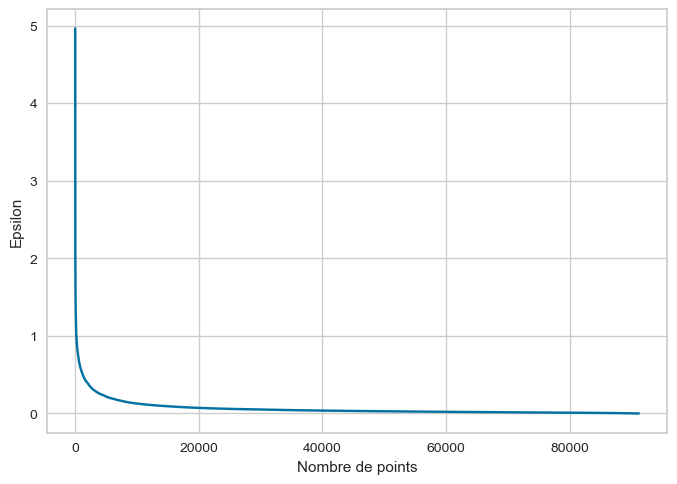

In [71]:
distances_triees = np.sort(distances[:,-1])[::-1]
plt.plot(distances_triees)
plt.xlabel("Nombre de points")
plt.ylabel("Epsilon")
plt.show()

In [72]:
nn = NearestNeighbors(n_neighbors=20).fit(df_rfm_scaled1)
distances, _ = nn.kneighbors(df_rfm_scaled1)

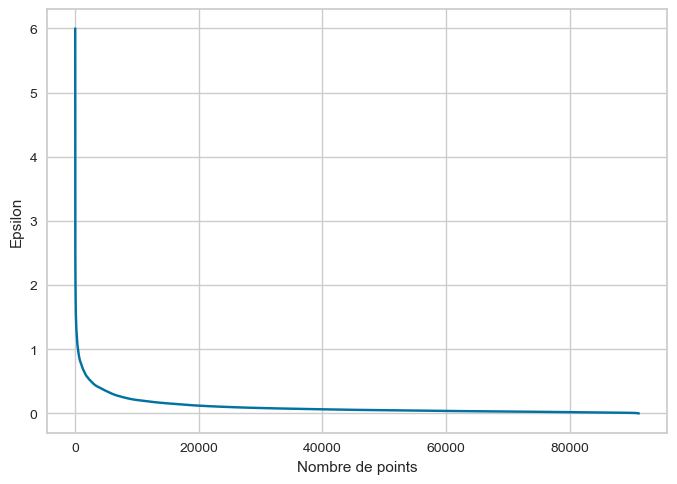

In [73]:
distances_triees = np.sort(distances[:,-1])[::-1]
plt.plot(distances_triees)
plt.xlabel("Nombre de points")
plt.ylabel("Epsilon")
plt.show()

In [74]:
minpts=8

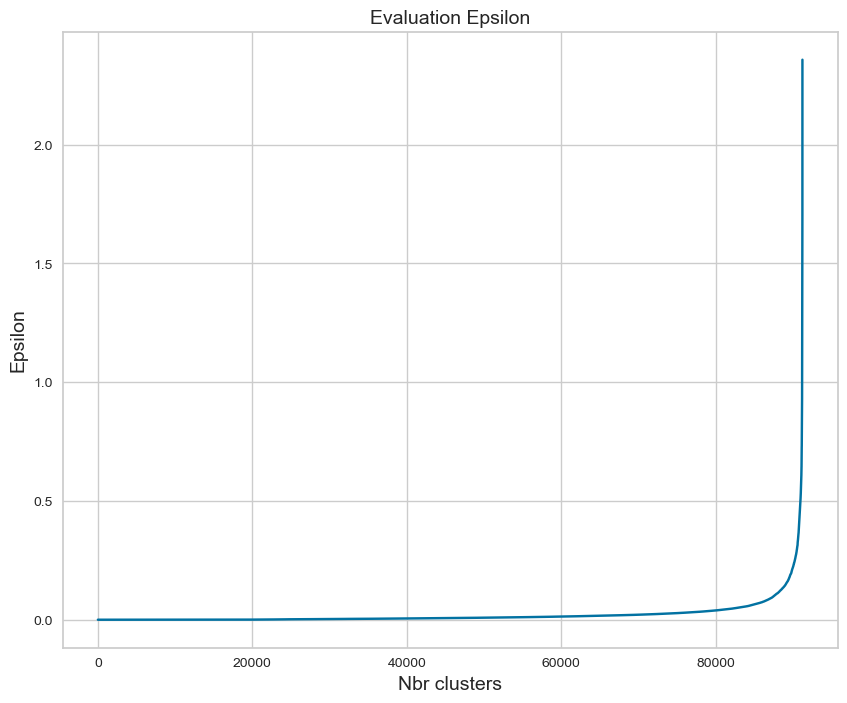

In [75]:
recherche_epsilon(df_rfm_scaled1, minpts)

In [76]:
def calcul_metrics_dbscan(data, dataframe_metrique, type_donnees, param_grid):
    '''
    Calcul des métriques de DBSCAN en fonction de différents paramètres.

    Parameters
    ----------
    data : données, obligatoire.
    dataframe_metrique : dataframe de sauvegarde des résultats, obligatoire.
    type_donnees : string intitulé des données, obligatoire.
    param_grid : la grille contenant les paramètres à optimiser.

    Returns
    -------
    dataframe_metrique : DataFrame contenant le résultat des métriques
    '''

    # Listes pour stocker les résultats
    silhouette = []
    davies_bouldin = []
    calin_harab = []
    donnees = []
    temps = []
    result_eps = []
    result_minsamples = []

    # Décomposition de la grille de paramètres
    eps = param_grid[0]
    min_samples = param_grid[1]
    n_jobs = param_grid[2]

    for epsilon in eps:
        for minsamples in min_samples:
            # Initialisation et entraînement de l'algorithme DBSCAN
            dbscan = DBSCAN(eps=epsilon, min_samples=minsamples, n_jobs=n_jobs)
            preds = dbscan.fit_predict(data)

            # Calcul des métriques
            silh = silhouette_score(data, preds)
            db = davies_bouldin_score(data, preds)
            cal_har = calinski_harabasz_score(data, preds)

            # Stockage des résultats
            silhouette.append(silh)
            davies_bouldin.append(db)
            calin_harab.append(cal_har)
            donnees.append(type_donnees)
            result_eps.append(epsilon)
            result_minsamples.append(minsamples)

    # Création d'un nouveau DataFrame pour stocker les résultats
    results_df = pd.DataFrame({
        'Type_données': donnees,
        'eps': result_eps,
        'min_samples': result_minsamples,
        'coef_silh': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calin_harab
    })

    # Concaténation avec le DataFrame de métriques existant
    dataframe_metrique = pd.concat([dataframe_metrique, results_df], ignore_index=True)

    return dataframe_metrique

In [77]:
df_metrics_dbscan = pd.DataFrame()

In [66]:
eps = [0.5, 1, 1.5,2]
min_samples = [10, 20, 30, 40]
n_jobs = 2
param_grid = [eps, min_samples, n_jobs]

df_metrics_dbscan = calcul_metrics_dbscan(df_rfm_scaled1, df_metrics_dbscan, 'DBSCAN quant log', param_grid)

In [67]:
df_metrics_dbscan

,Type_données,eps,min_samples,coef_silh,davies_bouldin,calinski_harabasz
0,DBSCAN quant log,0.5,10,0.11523,2.33862,5866.62900
1,DBSCAN quant log,0.5,20,0.10870,2.30173,6573.84212
2,DBSCAN quant log,0.5,30,0.10669,2.23371,6879.26433
3,DBSCAN quant log,0.5,40,0.10285,2.32692,7943.37334
4,DBSCAN quant log,1.0,10,0.37862,1.70543,17747.43310
5,DBSCAN quant log,1.0,20,0.37826,1.69396,17776.78336
6,DBSCAN quant log,1.0,30,0.37775,1.67452,17821.07544
7,DBSCAN quant log,1.0,40,0.37737,1.65243,17844.12593
8,DBSCAN quant log,1.5,10,0.43450,1.03442,18034.66097
9,DBSCAN quant log,1.5,20,0.43387,1.03237,18129.76998


In [83]:
# Instanciation de dbscan avec les meilleurs paramètres
dbscan = DBSCAN(eps=1,
                min_samples=10,
                n_jobs=2)
# Entraînement du modèle
dbscan.fit(df_rfm_scaled1)
dbscan_labels = dbscan.labels_

In [84]:
dbscan.labels_

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [85]:
df_rfm['K_Cluster_dbscan'] = dbscan.labels_

In [87]:
df_rfm['K_Cluster_dbscan'].value_counts(sort=False)

K_Cluster_dbscan
 0    70929
 1     9989
 2     6583
 3     3632
-1       90
Name: count, dtype: int64

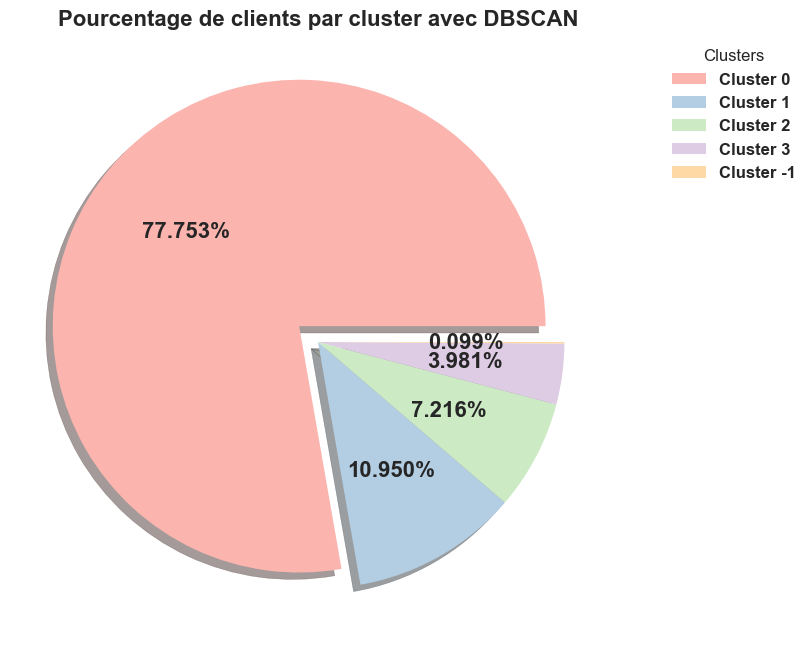

In [111]:
# Configuration de la figure
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(aspect='equal'))

# Configuration pour 'explode' (faire ressortir un secteur)
explode = (0.1, 0, 0,0,0)  # Ajustez en fonction du nombre de clusters

# Calcul des valeurs pour le diagramme
p = df_rfm['K_Cluster_dbscan'].value_counts()

# Générer des couleurs automatiquement en fonction du nombre de clusters
colors = plt.cm.Pastel1(range(len(p)))

# Création du diagramme en secteurs
p.plot(kind="pie", labels=None, startangle=0, explode=explode, autopct='%0.3f%%', 
       pctdistance=0.6, shadow=True, textprops={'weight': 'bold', 'fontsize': 16}, 
       colors=colors, ax=ax)

# Création des étiquettes de légende basées sur les clusters présents
legend_labels = [f'Cluster {i}' for i in p.index]

# Ajout de la légende
ax.legend(legend_labels, title="Clusters", loc='best', shadow=True, 
          prop={'weight': 'bold', 'size': 12}, bbox_to_anchor=(0.8, 0, 0.5, 1))

# Titre du diagramme
plt.title('Pourcentage de clients par cluster avec DBSCAN', fontweight='bold', size=16)

# Suppression du label de l'axe des y
plt.ylabel("")

# Affichage du diagramme
plt.show()

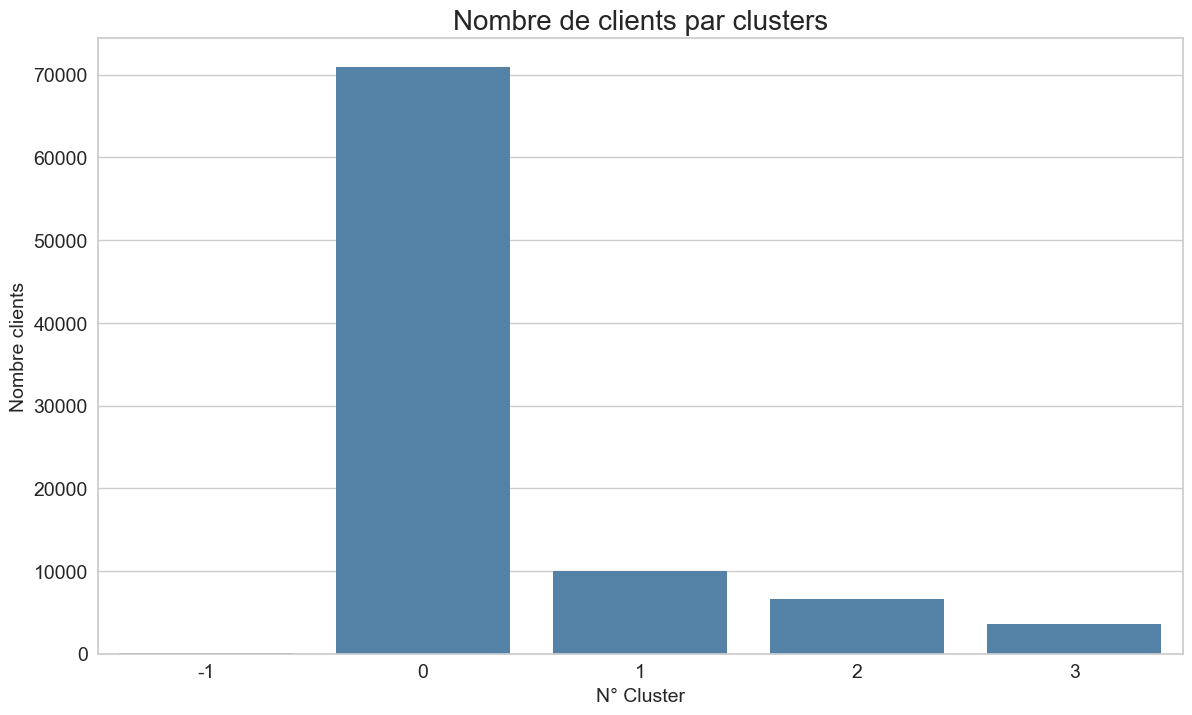

In [112]:
cluster_dbscan = df_rfm['K_Cluster_dbscan'].value_counts(sort=False)

# Countplot
plt.figure(figsize=(14, 8))
sns.barplot(x=cluster_dbscan.index, y=cluster_dbscan.values,
            color='SteelBlue')

plt.title('Nombre de clients par clusters',
          fontsize=20)
plt.ylabel('Nombre clients', fontsize=14)
plt.xlabel('N° Cluster', fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [113]:
df_rfm_dbscan=df_rfm[['rfm_recence', 'rfm_frequence', 'rfm_montant', 'rfm_review','K_Cluster_dbscan']]

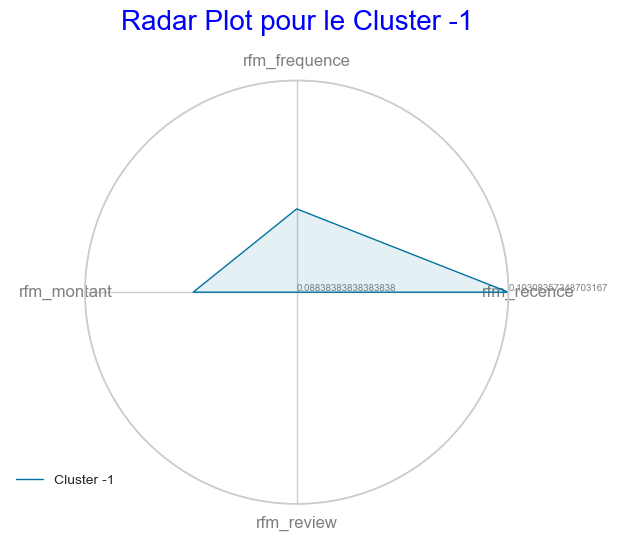

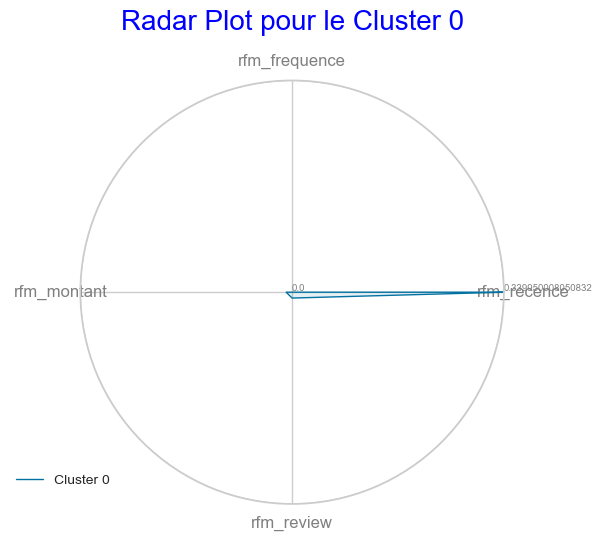

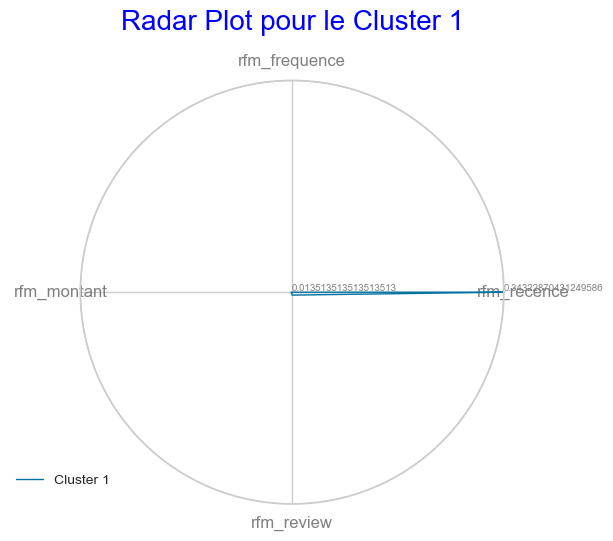

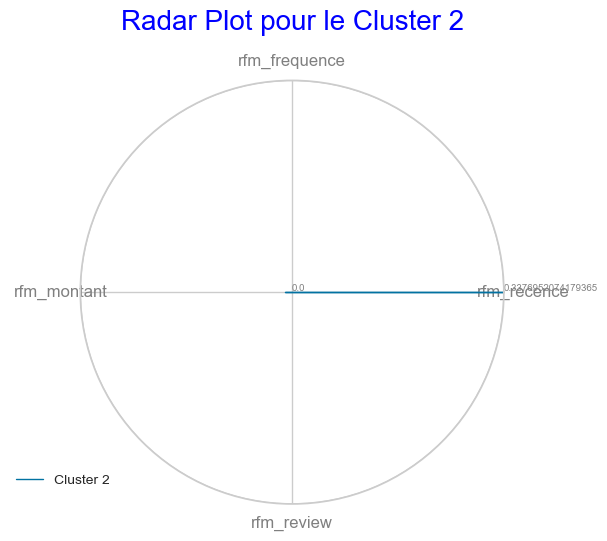

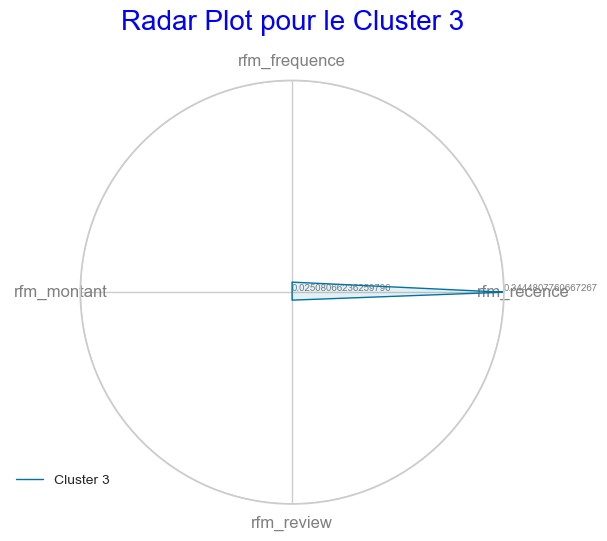

In [114]:
from math import pi

# Étape 1: Calcul des moyennes pour chaque cluster
# Remplacer `df_rfm` par votre DataFrame
cluster_means = df_rfm_dbscan.groupby('K_Cluster_dbscan').mean()

# Étape 2: Création des diagrammes radar pour chaque cluster
# Définition des catégories (variables rfm)
categories = ['rfm_recence', 'rfm_frequence', 'rfm_montant', 'rfm_review']
N = len(categories)

# Création d'une boucle pour générer un diagramme radar pour chaque cluster
for cluster in cluster_means.index:
    values = cluster_means.loc[cluster, categories].tolist()
    values += values[:1]  # pour fermer le cercle du diagramme radar

    # Calcul des angles pour chaque axe dans le radar
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Initialisation du diagramme radar
    ax = plt.subplot(111, polar=True)

    # Premier axe en haut
    plt.xticks(angles[:-1], categories, color='grey', size=12)

    # Dessin des lignes y
    ax.set_rlabel_position(0)
    plt.yticks([min(values), max(values)], [str(min(values)), str(max(values))], color="grey", size=7)
    plt.ylim(min(values), max(values))

    # Plot des données
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {cluster}')

    # Remplissage de l'aire
    ax.fill(angles, values, 'b', alpha=0.1)

    # Ajout d'un titre
    plt.title(f'Radar Plot pour le Cluster {cluster}', size=20, color='blue', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

    # Affichage du diagramme
    plt.show()




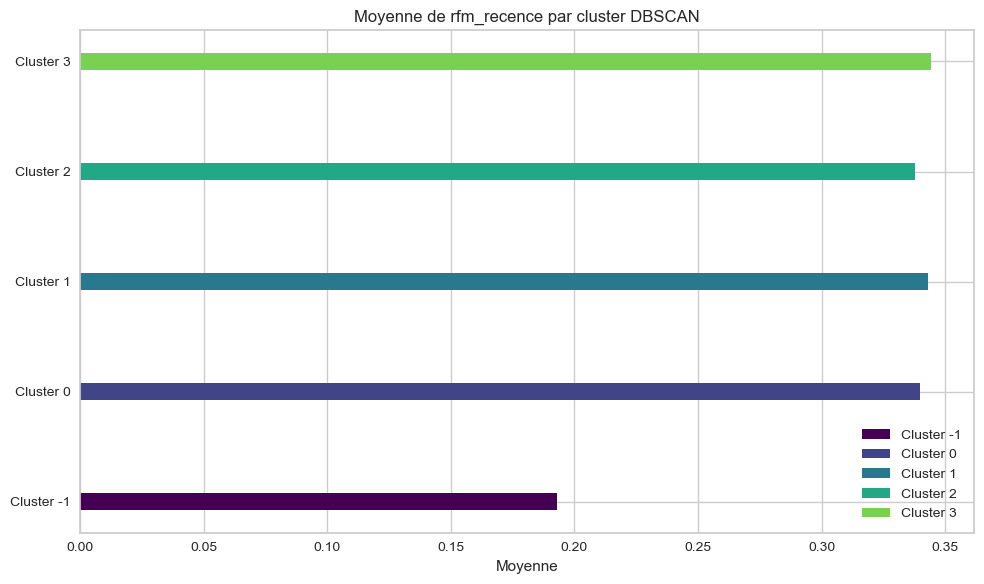

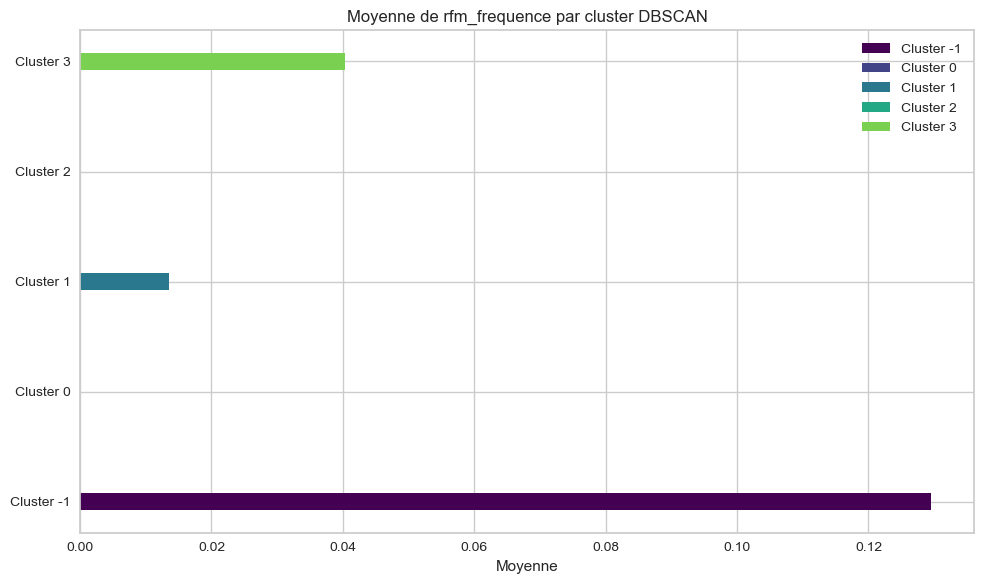

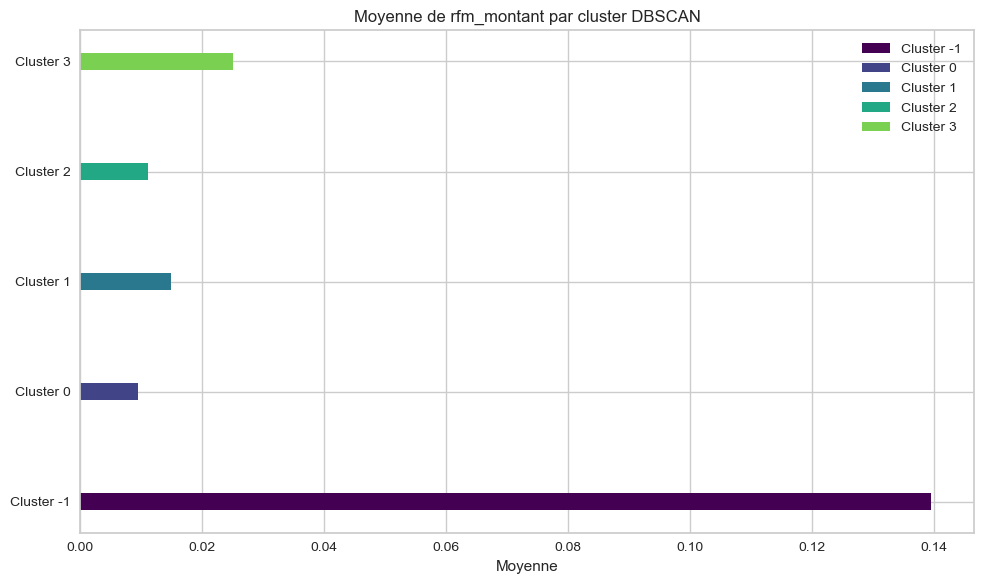

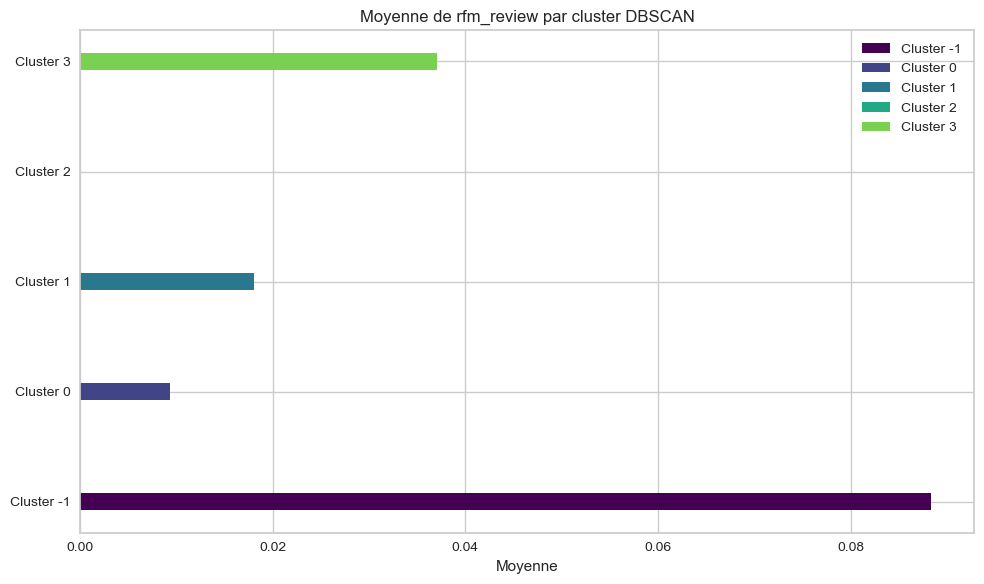

In [116]:
cluster_db = df_rfm_dbscan.groupby('K_Cluster_dbscan').mean()

# Liste des variables à tracer
variables = ['rfm_recence', 'rfm_frequence', 'rfm_montant', 'rfm_review']

# Configuration de la visualisation
num_clusters = cluster_db.shape[0]
bar_width = 0.15  # Largeur des barres

# Utilisation d'une palette de couleurs qui inclut un élément supplémentaire pour les outliers
colors = plt.cm.viridis(np.linspace(0, 1, num_clusters + 1))  # +1 pour inclure les outliers

# Tracer un graphique en barres pour chaque variable
for variable in variables:
    plt.figure(figsize=(10, 6))
    
    # Récupération des indices des clusters, en incluant les outliers
    clusters = cluster_db.index
    
    # Tracé des barres pour chaque cluster
    for i, cluster in enumerate(clusters):
        plt.barh(i, cluster_db.loc[cluster, variable], bar_width, color=colors[i], label=f'Cluster {cluster}')
    
    plt.xlabel('Moyenne')
    plt.title(f'Moyenne de {variable} par cluster DBSCAN')
    plt.yticks(np.arange(len(clusters)), [f'Cluster {c}' for c in clusters])
    
    # Ajout de la légende
    plt.legend()

    plt.tight_layout()
    plt.show()

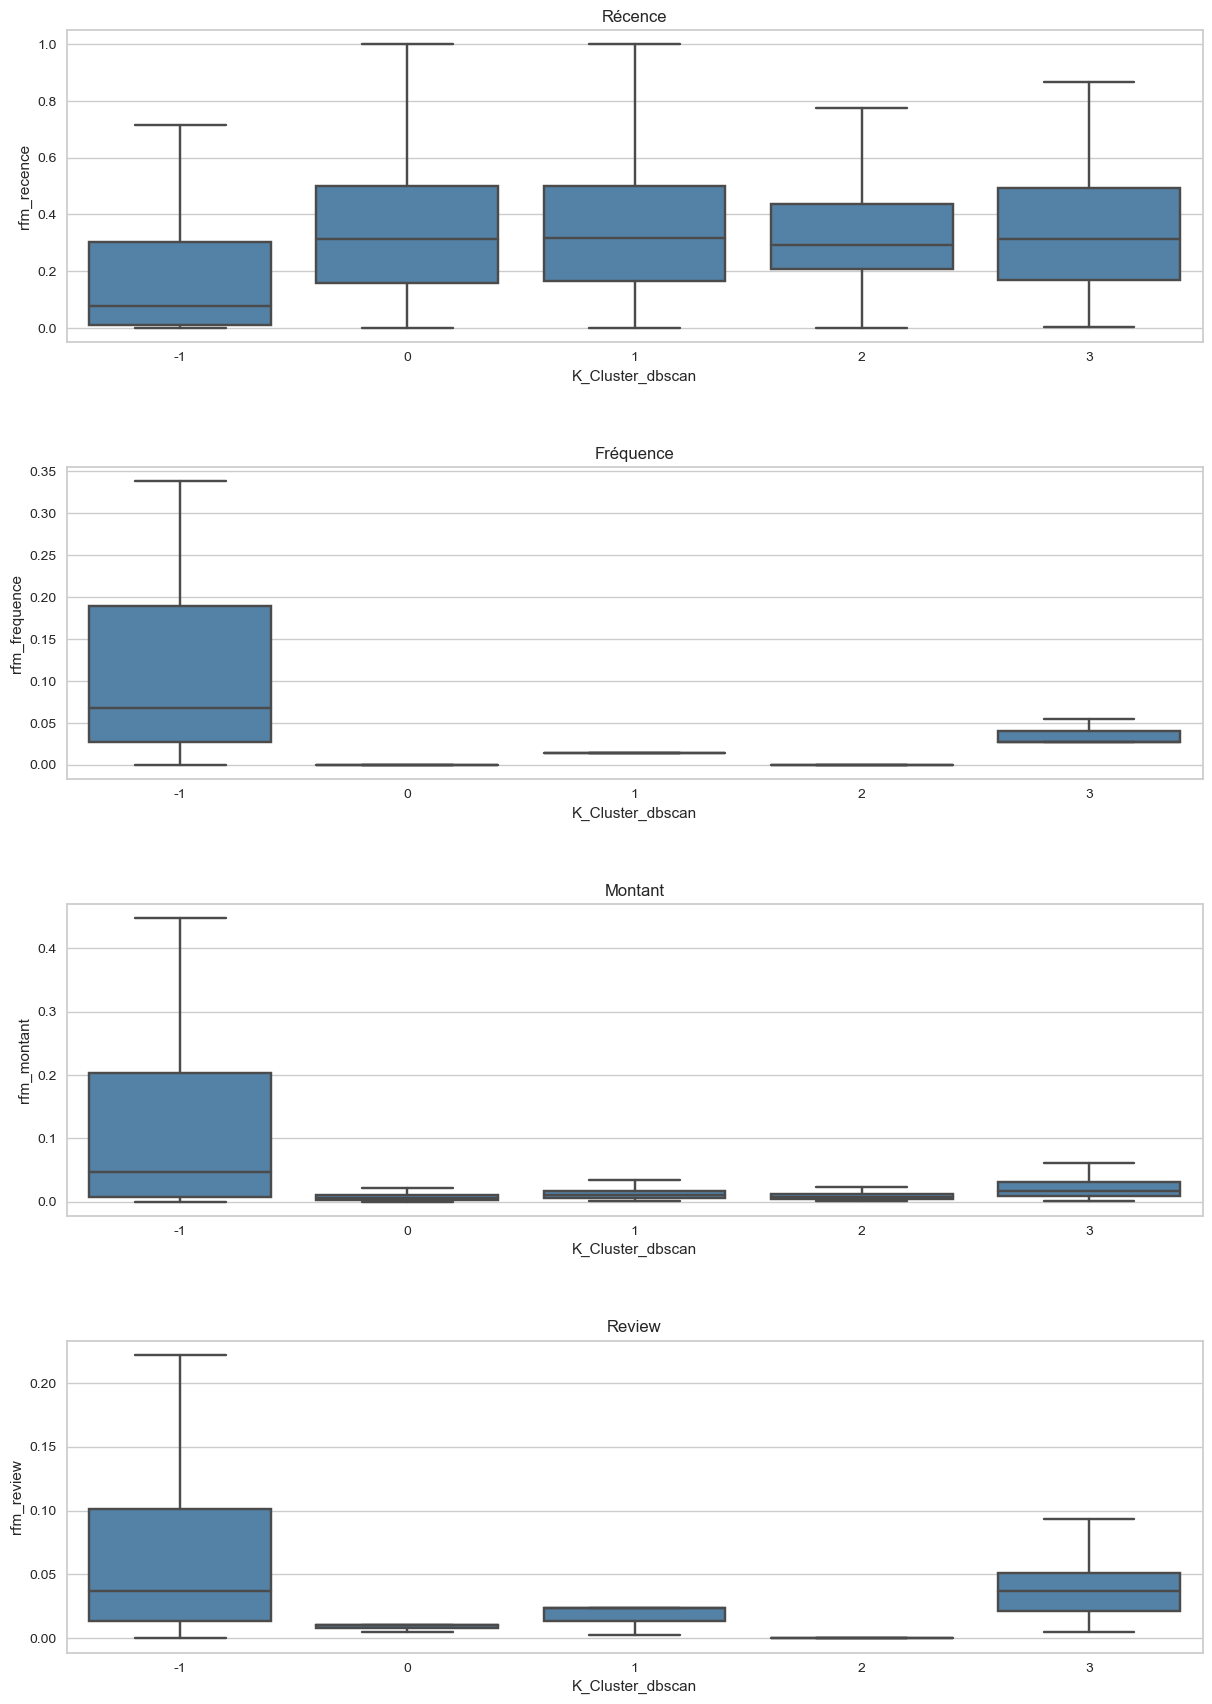

In [149]:
# Boîte à moustache des types de client
# --------------------------------------------------------------------
fig, axs = plt.subplots(4, 1)
fig.subplots_adjust(left=0.08, right=1.5, bottom=0.05,
                    top=3, hspace=0.4, wspace=0.3)

# Boxplot Récence
sns.boxplot(x='K_Cluster_dbscan', y='rfm_recence', data=df_rfm_dbscan,
            color='SteelBlue', ax=axs[0],showfliers=False)
axs[0].set_title('Récence')

# Boxplot Fréquence
sns.boxplot(x='K_Cluster_dbscan', y='rfm_frequence', data=df_rfm_dbscan,
            color='SteelBlue', ax=axs[1],showfliers=False)
axs[1].set_title('Fréquence')

# Boxplot Montant
sns.boxplot(x='K_Cluster_dbscan', y='rfm_montant', data=df_rfm_dbscan,
            color='SteelBlue', ax=axs[2],showfliers=False)
axs[2].set_title('Montant')
# Boxplot Review
sns.boxplot(x='K_Cluster_dbscan', y='rfm_review', data=df_rfm_dbscan,
            color='SteelBlue', ax=axs[3],showfliers=False)
axs[3].set_title('Review')

plt.show()

# CAH

In [117]:
def calcul_metrics_cah(data, dataframe_metrique, type_donnees,
                      param_grid_cah):
    '''
    Calcul des métriques de CAH en fonction de différents paramètres.
    Parameters
    ----------
    data : données, obligatoire.
    dataframe_metrique : dataframe de sauvegarde des résultats, obligatoire.
    type_donnees : string intitulé des données, obligatoire.
    random_seed : nombre aléatoire pour la reproductibilité, obligatoire.
    param_grid : la grille contenant les paramètres à optimiser.
    Returns
    -------
    dataframe_metrique : résultat des métriques
    '''
    # Cette fonction permet de calculer le nombre de clusters le plus
    # optimal pour notre analyse : le coefficient de silhouette,
    # indice de davies_bouldin, indice de Calinsky-Harabasz
    silhouette = []
    davies_bouldin = []
    calin_harab = []
    donnees = []
    temps = []

    result_nclusters = []
    result_linkage = []
    result_affinity = []

    # Hyperparametre tuning
    n_clusters = param_grid_cah[0]
    linkage = param_grid_cah[1]
    affinity = param_grid_cah[2]

    # Tester le modèle avec les différentes combinaisons de paramètres
    for nb_clusters in n_clusters:

        for link in linkage:

            for affinite in affinity:

                # Top début d'exécution
                time_start = time.time()

                # Initialisation de l'algorithme
                cah = AgglomerativeClustering(n_clusters=nb_clusters,
                                              linkage=link,
                                              affinity=affinite)

                # Entraînement de l'algorithme / Prédictions
                preds = cah.fit_predict(data)

                # Top fin d'exécution
                time_end = time.time()

                # Calcul du score de coefficient de silhouette
                silh = silhouette_score(data, preds)
                # Calcul de l'indice davies-bouldin
                db = davies_bouldin_score(data, preds)
                # Calcul de l'indice  Calinski_harabasz
                cal_har = calinski_harabasz_score(data, preds)
                # Durée d'exécution
                time_execution = time_end - time_start

                silhouette.append(silh)
                davies_bouldin.append(db)
                calin_harab.append(cal_har)
                donnees.append(type_donnees)
                temps.append(time_execution)

                result_nclusters.append(nb_clusters)
                result_linkage.append(link)
                result_affinity.append(affinite)
 # Création d'un nouveau DataFrame pour stocker les résultats
    results_df = pd.DataFrame({
        'Type_données': donnees,
        'n_clusters': result_nclusters,
        'linkage': result_linkage,
        'affinity': result_affinity,
        'coef_silh': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calin_harab,
        'Durée (s)': temps
    })

    # Concaténation avec le DataFrame de métriques existant
    dataframe_metrique = pd.concat([dataframe_metrique, results_df], ignore_index=True)
   
 

    return dataframe_metrique


In [118]:
# Dataframe de sauvegarde des résultats des métriques CAH
df_metrics_cah = pd.DataFrame()

In [119]:
# Impossible de lancer CAH sur plus de 35000 clients à cause de problème
# de mémoire ==> on lance sur 15000 clients
data_reduit = df_rfm_scaled.sample(20000).copy()
X_reduit = data_reduit.values
X_names = data_reduit.index

In [120]:
# Tuning hyperparametres n_clusters, linkage, affinity
# --------------------------------------------------------------------
# Métriques pour les données quantitatives standardisées transformées
# en standard_scaler et log
n_clusters = range(3, 10)
linkage = ['complete', 'average', 'single']
affinity = ['euclidean', 'manhattan', 'cosine']
param_grid_cah = [n_clusters, linkage, affinity]
# Métriques avec les différentes combinaisons des paramètres
df_metrics_cah = calcul_metrics_cah(X_reduit, df_metrics_cah, 'CAH quant log', param_grid_cah)


In [121]:
df_metrics_cah

,Type_données,n_clusters,linkage,affinity,coef_silh,davies_bouldin,calinski_harabasz,Durée (s)
0,CAH quant log,3,complete,euclidean,0.61748,0.51704,49746.58506,13.72963
1,CAH quant log,3,complete,manhattan,0.61748,0.51704,49746.58506,13.37342
2,CAH quant log,3,complete,cosine,0.32287,0.92590,5689.94650,13.90020
3,CAH quant log,3,average,euclidean,0.60109,0.48838,46875.43067,13.72213
4,CAH quant log,3,average,manhattan,0.60109,0.48838,46875.43067,13.95782
5,CAH quant log,3,average,cosine,0.31273,0.66121,5689.65912,13.75376
6,CAH quant log,3,single,euclidean,0.51292,0.43661,20667.72870,2.65101
7,CAH quant log,3,single,manhattan,0.51292,0.43661,20667.72870,1.90772
8,CAH quant log,3,single,cosine,0.31273,0.66121,5689.65912,5.07588
9,CAH quant log,4,complete,euclidean,0.67883,0.42267,58309.70223,13.70471


In [122]:
# Coefficient de silhouette : le plus proche de 1 possible
df_metrics_cah.sort_values(by='coef_silh', ascending=False)

,Type_données,n_clusters,linkage,affinity,coef_silh,davies_bouldin,calinski_harabasz,Durée (s)
25,CAH quant log,5,single,manhattan,0.80612,0.31286,198878.97605,2.01510
18,CAH quant log,5,complete,euclidean,0.80612,0.31286,198878.97605,14.43480
19,CAH quant log,5,complete,manhattan,0.80612,0.31286,198878.97605,13.66844
21,CAH quant log,5,average,euclidean,0.80612,0.31286,198878.97605,14.76584
22,CAH quant log,5,average,manhattan,0.80612,0.31286,198878.97605,15.71360
24,CAH quant log,5,single,euclidean,0.80612,0.31286,198878.97605,2.67780
28,CAH quant log,6,complete,manhattan,0.77464,0.36842,178901.79204,13.27442
34,CAH quant log,6,single,manhattan,0.77439,0.40575,159196.81012,1.89172
33,CAH quant log,6,single,euclidean,0.77230,0.45933,159225.77060,2.59226
31,CAH quant log,6,average,manhattan,0.76445,0.37485,159219.46530,14.51220


In [123]:
# Indice de Davies-Bouldin : le plus proche de 0.
df_metrics_cah.sort_values(by='davies_bouldin')

,Type_données,n_clusters,linkage,affinity,coef_silh,davies_bouldin,calinski_harabasz,Durée (s)
30,CAH quant log,6,average,euclidean,0.73147,0.30644,160435.09304,13.83633
39,CAH quant log,7,average,euclidean,0.65104,0.31239,133734.80768,13.94624
21,CAH quant log,5,average,euclidean,0.80612,0.31286,198878.97605,14.76584
25,CAH quant log,5,single,manhattan,0.80612,0.31286,198878.97605,2.01510
24,CAH quant log,5,single,euclidean,0.80612,0.31286,198878.97605,2.67780
22,CAH quant log,5,average,manhattan,0.80612,0.31286,198878.97605,15.71360
18,CAH quant log,5,complete,euclidean,0.80612,0.31286,198878.97605,14.43480
19,CAH quant log,5,complete,manhattan,0.80612,0.31286,198878.97605,13.66844
27,CAH quant log,6,complete,euclidean,0.73963,0.35496,204057.24912,13.29174
52,CAH quant log,8,single,manhattan,0.76125,0.36156,113734.37846,1.92329


In [124]:
# Score de Calinski-Harabsz : le plus grand possible
df_metrics_cah.sort_values(by='calinski_harabasz', ascending=False)

,Type_données,n_clusters,linkage,affinity,coef_silh,davies_bouldin,calinski_harabasz,Durée (s)
54,CAH quant log,9,complete,euclidean,0.60161,0.45475,219322.66904,13.50156
27,CAH quant log,6,complete,euclidean,0.73963,0.35496,204057.24912,13.29174
37,CAH quant log,7,complete,manhattan,0.71642,0.40462,202448.90435,13.39131
18,CAH quant log,5,complete,euclidean,0.80612,0.31286,198878.97605,14.43480
25,CAH quant log,5,single,manhattan,0.80612,0.31286,198878.97605,2.01510
24,CAH quant log,5,single,euclidean,0.80612,0.31286,198878.97605,2.67780
22,CAH quant log,5,average,manhattan,0.80612,0.31286,198878.97605,15.71360
21,CAH quant log,5,average,euclidean,0.80612,0.31286,198878.97605,14.76584
19,CAH quant log,5,complete,manhattan,0.80612,0.31286,198878.97605,13.66844
36,CAH quant log,7,complete,euclidean,0.70229,0.39206,187809.31328,13.41318


In [125]:
# Constitution du dataframes de visualisation
df_cah = \
    df_metrics_cah[df_metrics_cah['Type_données'] == 'CAH quant log']

In [126]:
def affiche_effet_clusters_score(dataframe, nclust_deb, nclust_fin, silh=True,
                                 davbou=True, calhar=True):
    '''
    Affiche les graphiques des différents scores des clusters.
    Parameters
    ----------
    dataframe : dataframe de résultats des métriques, obligatoire.
    nclust_deb : nombre de clusters minimum, obligatoire.
    nclust_fin : nombre de clusters maximum, obligatoire.
    silh : Affiche graphique score des silhouettes?, optionnel (défaut : True)
    davbou : Affiche graphique des indices de Davies-Bouldin?,
             optionnel (défaut : True)
    calhar : Affiche graphique des indices de Calinski-Harabasz?,
             optionnel (défaut : True)
    Returns
    -------
    None.
    '''
    if silh:
        # Trace le graphique des coefficient de silhouette
        plt.figure(figsize=(12, 5))

        s_silhouette = dataframe.groupby('n_clusters')['coef_silh'].mean()

        plt.title('Le coefficient de silhouette', fontsize=16)
        plt.plot([i for i in range(nclust_deb, nclust_fin)], s_silhouette,
                 marker='o')
        plt.grid(True)
        plt.xlabel('Nombre de groupes', fontsize=14)
        plt.ylabel('Silhouette score', fontsize=15)
        plt.xticks([i for i in range(nclust_deb, nclust_fin)], fontsize=14)
        plt.yticks(fontsize=15)

        plt.show()

    if davbou:
        # Trace le graphique des indices de davies-bouldin
        plt.figure(figsize=(12, 5))

        s_db = dataframe.groupby('n_clusters')['davies_bouldin'].mean()

        plt.title('L\'indice de Davies-Bouldin', fontsize=16)
        plt.plot([i for i in range(nclust_deb, nclust_fin)], s_db, marker='o')

        plt.grid(True)
        plt.xlabel('Nombre de groupes', fontsize=14)
        plt.ylabel('Indice de Davies-Bouldin', fontsize=15)
        plt.xticks([i for i in range(nclust_deb, nclust_fin)], fontsize=14)
        plt.yticks(fontsize=15)

        plt.show()

    if calhar:
        # Trace le graphique des indices de Calinski-Harabasz
        plt.figure(figsize=(12, 5))

        s_db = dataframe.groupby('n_clusters')['calinski_harabasz'].mean()

        plt.title('L\'indice de Calinski-Harabasz', fontsize=16)
        plt.plot([i for i in range(nclust_deb, 10)], s_db, marker='o')

        plt.grid(True)
        plt.xlabel('Nombre de groupes', fontsize=14)
        plt.ylabel('Indice de Calinski-Harabasz', fontsize=15)
        plt.xticks([i for i in range(nclust_deb, nclust_fin)], fontsize=14)
        plt.yticks(fontsize=15)

        plt.show()



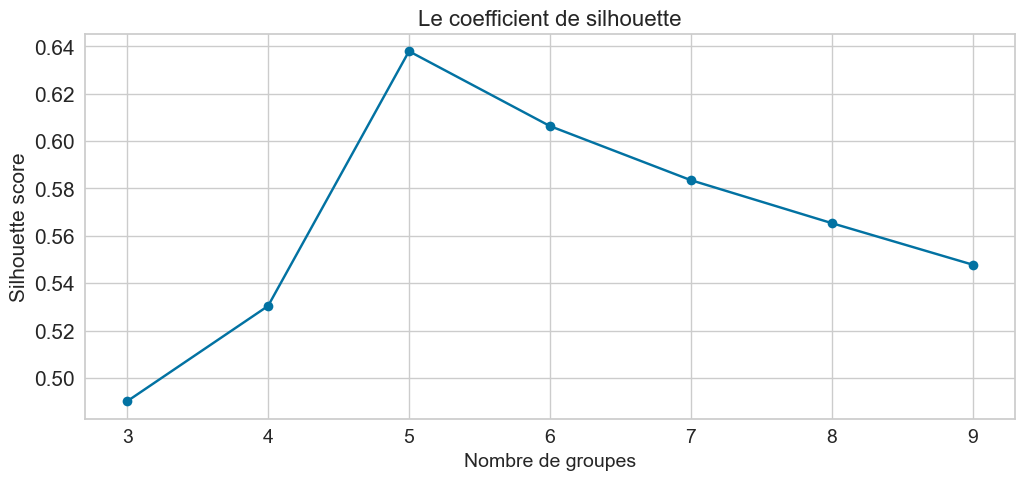

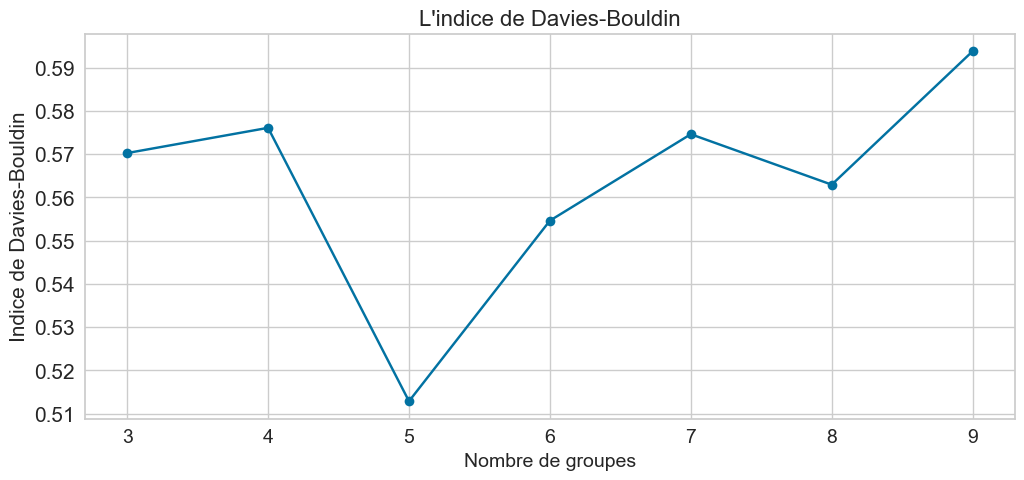

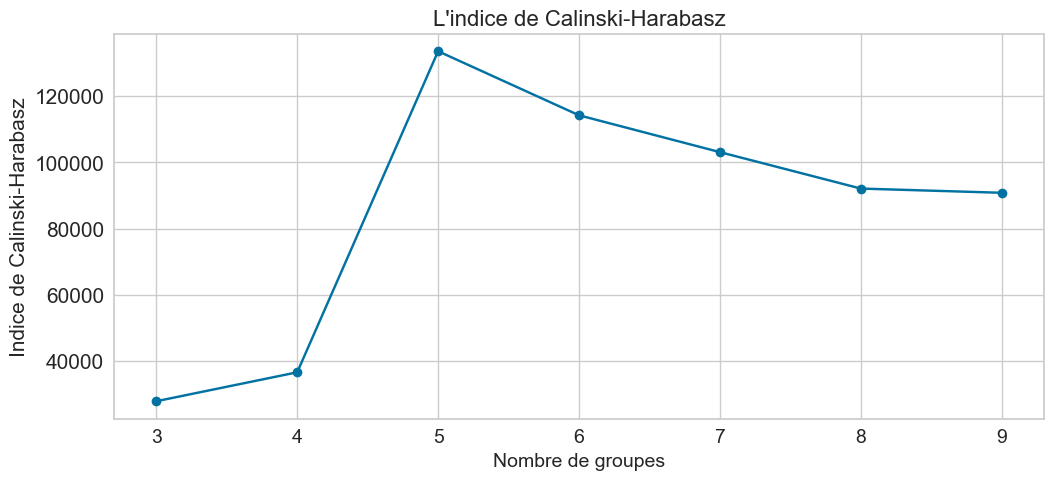

In [127]:
# Visualisation de l'effet des clusters sur les scores
affiche_effet_clusters_score(df_cah, 3, 10)

In [131]:
# Instanciation de cah avec les meilleurs paramètres
cah = AgglomerativeClustering(n_clusters=5,
                              linkage='single',
                              affinity='euclidean')
# Entraînement du modèle
cah.fit(X_reduit)
cah_labels = cah.labels_

In [132]:
cah_labels

array([4, 4, 1, ..., 2, 3, 4], dtype=int64)

In [134]:
data_reduit['K_Cluster_CAH'] = cah_labels

In [135]:
data_reduit['K_Cluster_CAH'].value_counts(sort=False)

K_Cluster_CAH
4    6386
1    6083
0    2608
2    2843
3    2080
Name: count, dtype: int64

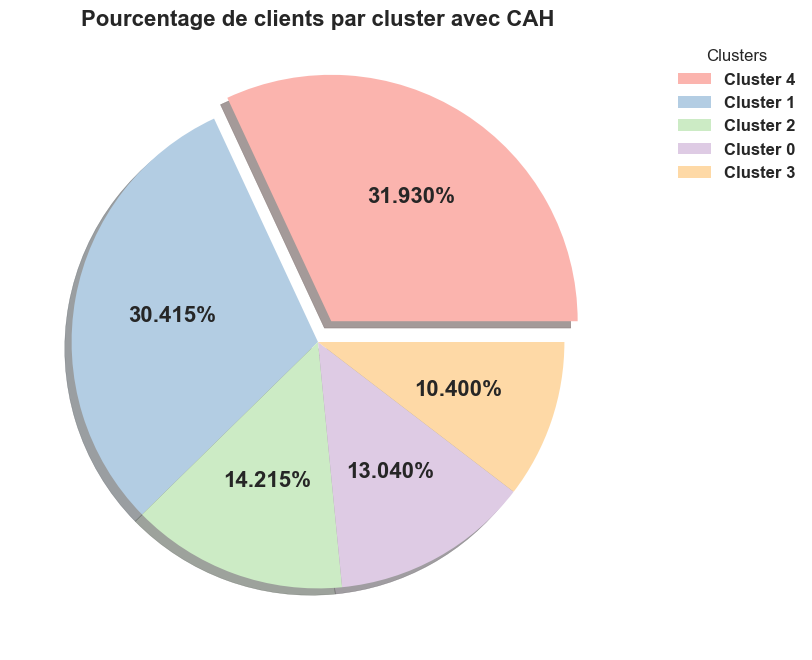

In [136]:
# Configuration de la figure
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(aspect='equal'))

# Configuration pour 'explode' (faire ressortir un secteur)
explode = (0.1, 0, 0,0,0)  # Ajustez en fonction du nombre de clusters

# Calcul des valeurs pour le diagramme
p = data_reduit['K_Cluster_CAH'].value_counts()

# Générer des couleurs automatiquement en fonction du nombre de clusters
colors = plt.cm.Pastel1(range(len(p)))

# Création du diagramme en secteurs
p.plot(kind="pie", labels=None, startangle=0, explode=explode, autopct='%0.3f%%', 
       pctdistance=0.6, shadow=True, textprops={'weight': 'bold', 'fontsize': 16}, 
       colors=colors, ax=ax)

# Création des étiquettes de légende basées sur les clusters présents
legend_labels = [f'Cluster {i}' for i in p.index]

# Ajout de la légende
ax.legend(legend_labels, title="Clusters", loc='best', shadow=True, 
          prop={'weight': 'bold', 'size': 12}, bbox_to_anchor=(0.8, 0, 0.5, 1))

# Titre du diagramme
plt.title('Pourcentage de clients par cluster avec CAH', fontweight='bold', size=16)

# Suppression du label de l'axe des y
plt.ylabel("")

# Affichage du diagramme
plt.show()

In [137]:
df_reduit_CAH=data_reduit[['rfm_recence', 'rfm_frequence', 'rfm_montant', 'rfm_review','K_Cluster_CAH']]

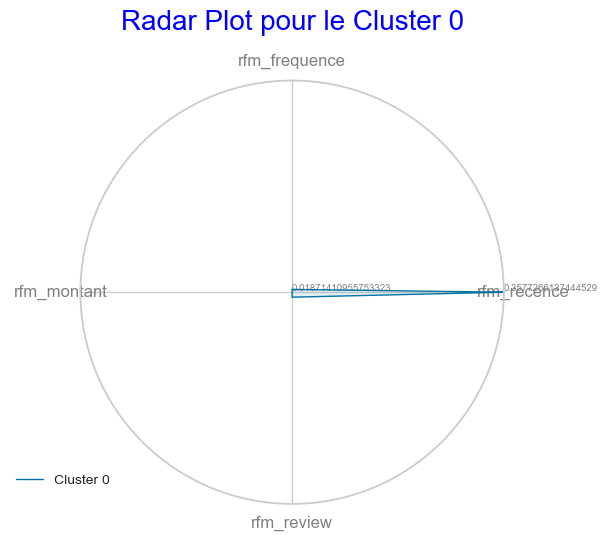

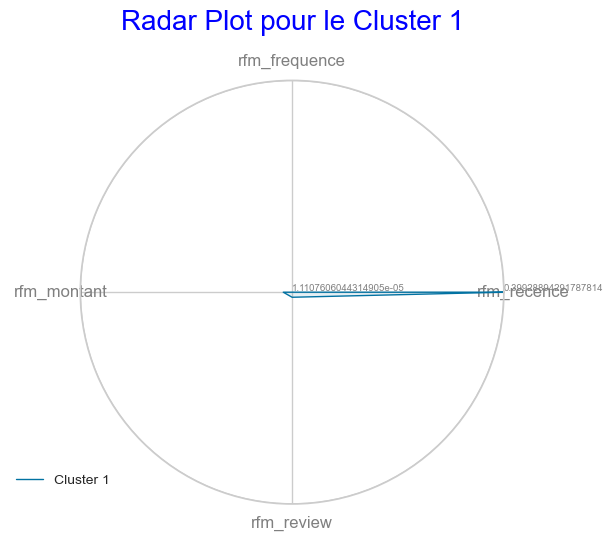

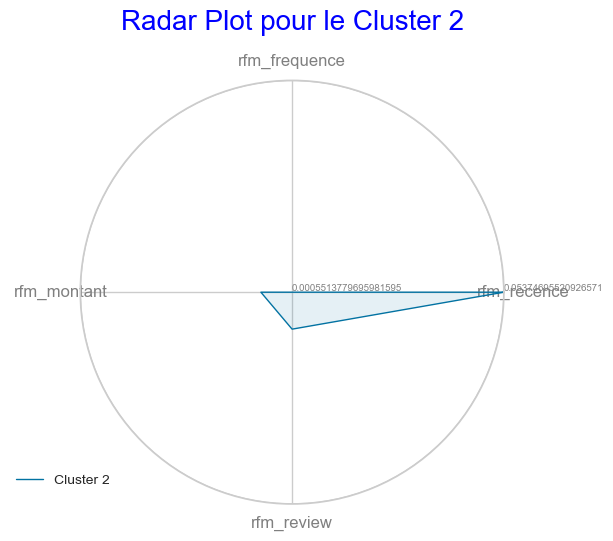

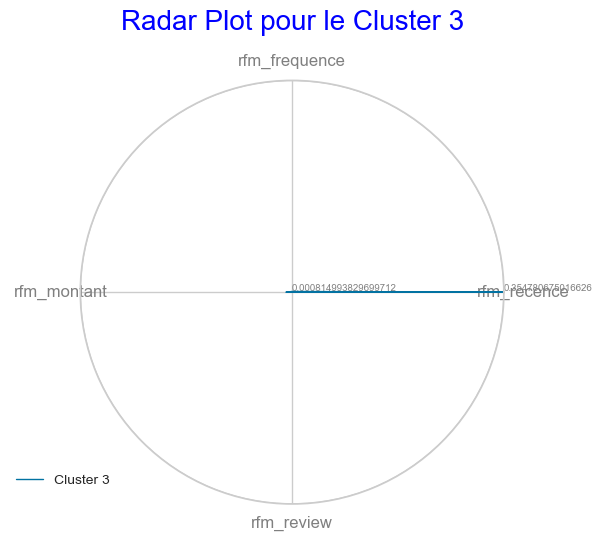

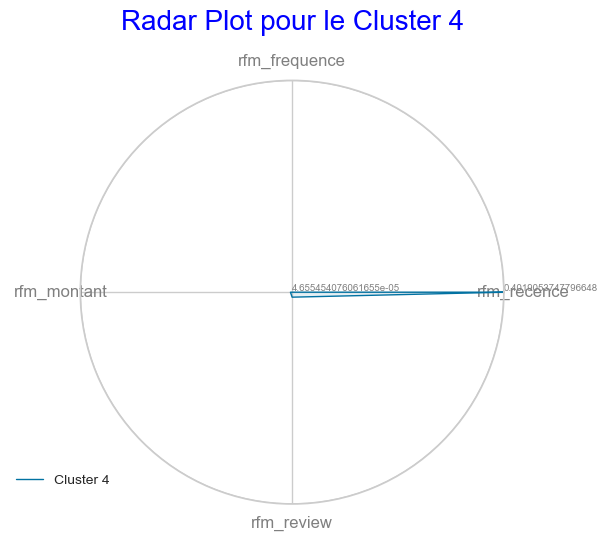

In [138]:
from math import pi

# Étape 1: Calcul des moyennes pour chaque cluster
# Remplacer `df_rfm` par votre DataFrame
cluster_CAH = df_reduit_CAH.groupby('K_Cluster_CAH').mean()

# Étape 2: Création des diagrammes radar pour chaque cluster
# Définition des catégories (variables rfm)
categories = ['rfm_recence', 'rfm_frequence', 'rfm_montant', 'rfm_review']
N = len(categories)

# Création d'une boucle pour générer un diagramme radar pour chaque cluster
for cluster in cluster_CAH.index:
    values = cluster_CAH.loc[cluster, categories].tolist()
    values += values[:1]  # pour fermer le cercle du diagramme radar

    # Calcul des angles pour chaque axe dans le radar
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Initialisation du diagramme radar
    ax = plt.subplot(111, polar=True)

    # Premier axe en haut
    plt.xticks(angles[:-1], categories, color='grey', size=12)

    # Dessin des lignes y
    ax.set_rlabel_position(0)
    plt.yticks([min(values), max(values)], [str(min(values)), str(max(values))], color="grey", size=7)
    plt.ylim(min(values), max(values))

    # Plot des données
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {cluster}')

    # Remplissage de l'aire
    ax.fill(angles, values, 'b', alpha=0.1)

    # Ajout d'un titre
    plt.title(f'Radar Plot pour le Cluster {cluster}', size=20, color='blue', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

    # Affichage du diagramme
    plt.show()



In [141]:
df_reduit_CAH['K_Cluster_CAH'].value_counts()

K_Cluster_CAH
4    6386
1    6083
2    2843
0    2608
3    2080
Name: count, dtype: int64

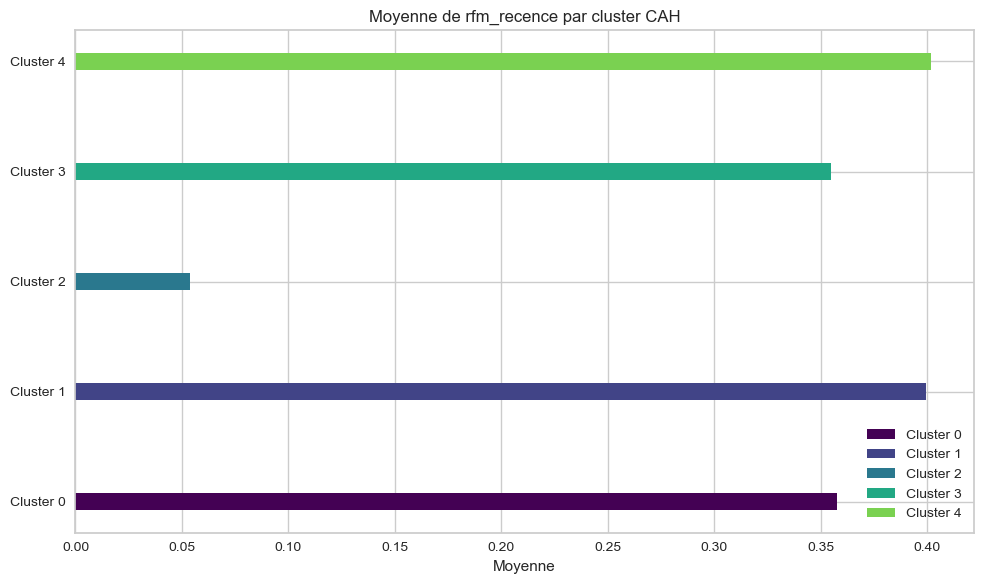

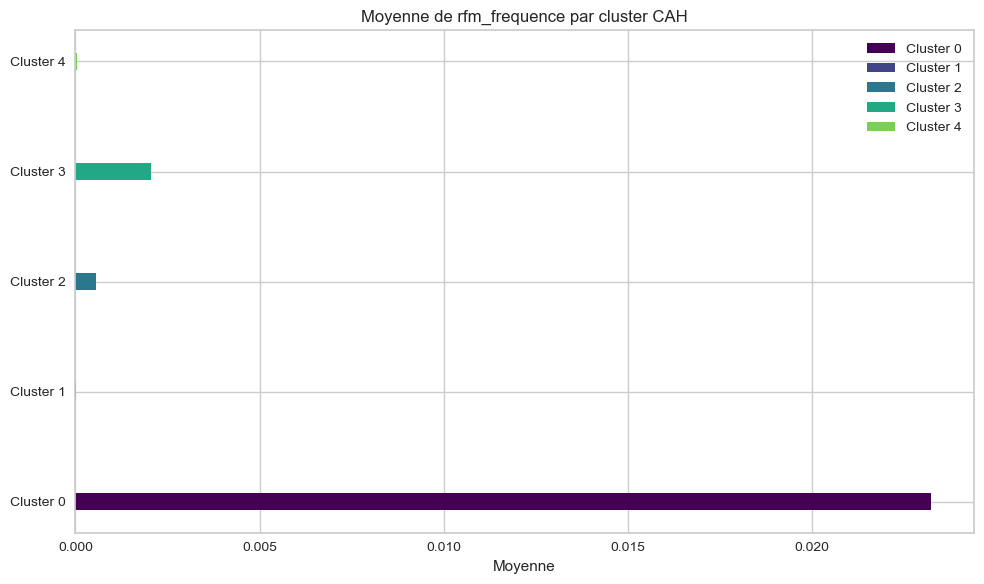

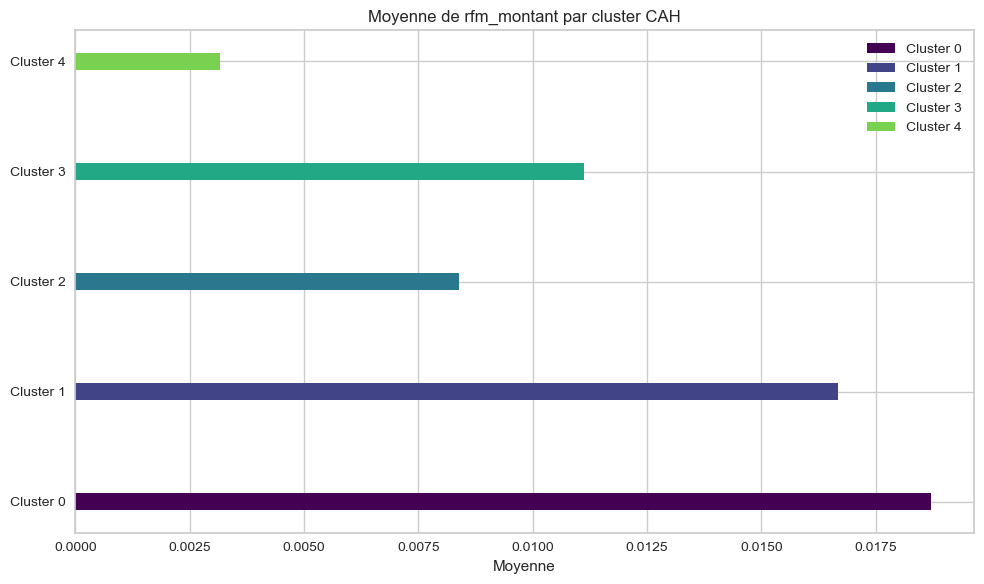

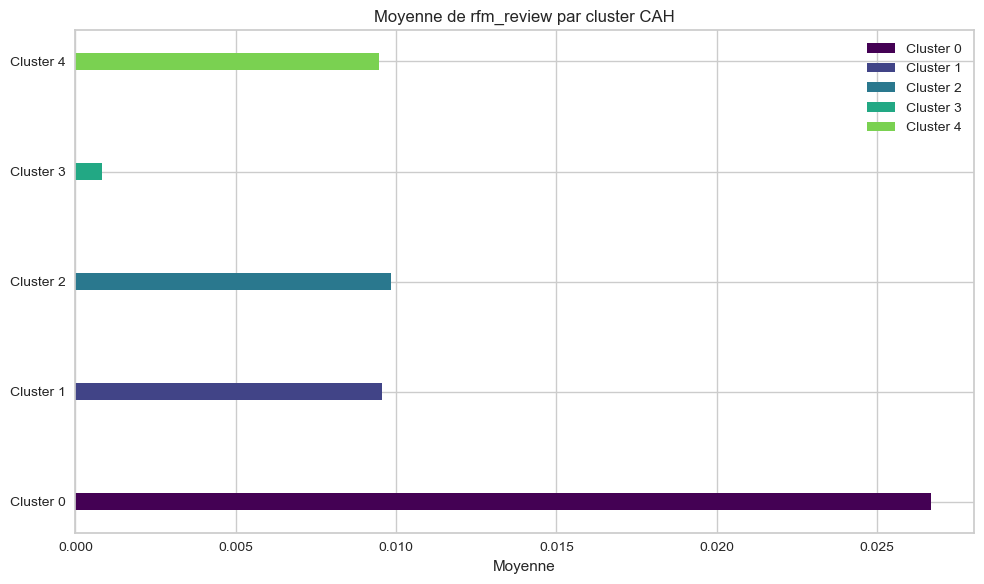

In [143]:
cluster_CAH = df_reduit_CAH.groupby('K_Cluster_CAH').mean()

# Liste des variables à tracer
variables = ['rfm_recence', 'rfm_frequence', 'rfm_montant', 'rfm_review']

# Configuration de la visualisation
num_clusters = cluster_CAH.shape[0]
bar_width = 0.15  # Largeur des barres

# Utilisation d'une palette de couleurs qui inclut un élément supplémentaire pour les outliers
colors = plt.cm.viridis(np.linspace(0, 1, num_clusters + 1))  # +1 pour inclure les outliers

# Tracer un graphique en barres pour chaque variable
for variable in variables:
    plt.figure(figsize=(10, 6))
    
    # Récupération des indices des clusters, en incluant les outliers
    clusters = cluster_CAH.index
    
    # Tracé des barres pour chaque cluster
    for i, cluster in enumerate(clusters):
        plt.barh(i, cluster_CAH.loc[cluster, variable], bar_width, color=colors[i], label=f'Cluster {cluster}')
    
    plt.xlabel('Moyenne')
    plt.title(f'Moyenne de {variable} par cluster CAH')
    plt.yticks(np.arange(len(clusters)), [f'Cluster {c}' for c in clusters])
    
    # Ajout de la légende
    plt.legend()

    plt.tight_layout()
    plt.show()

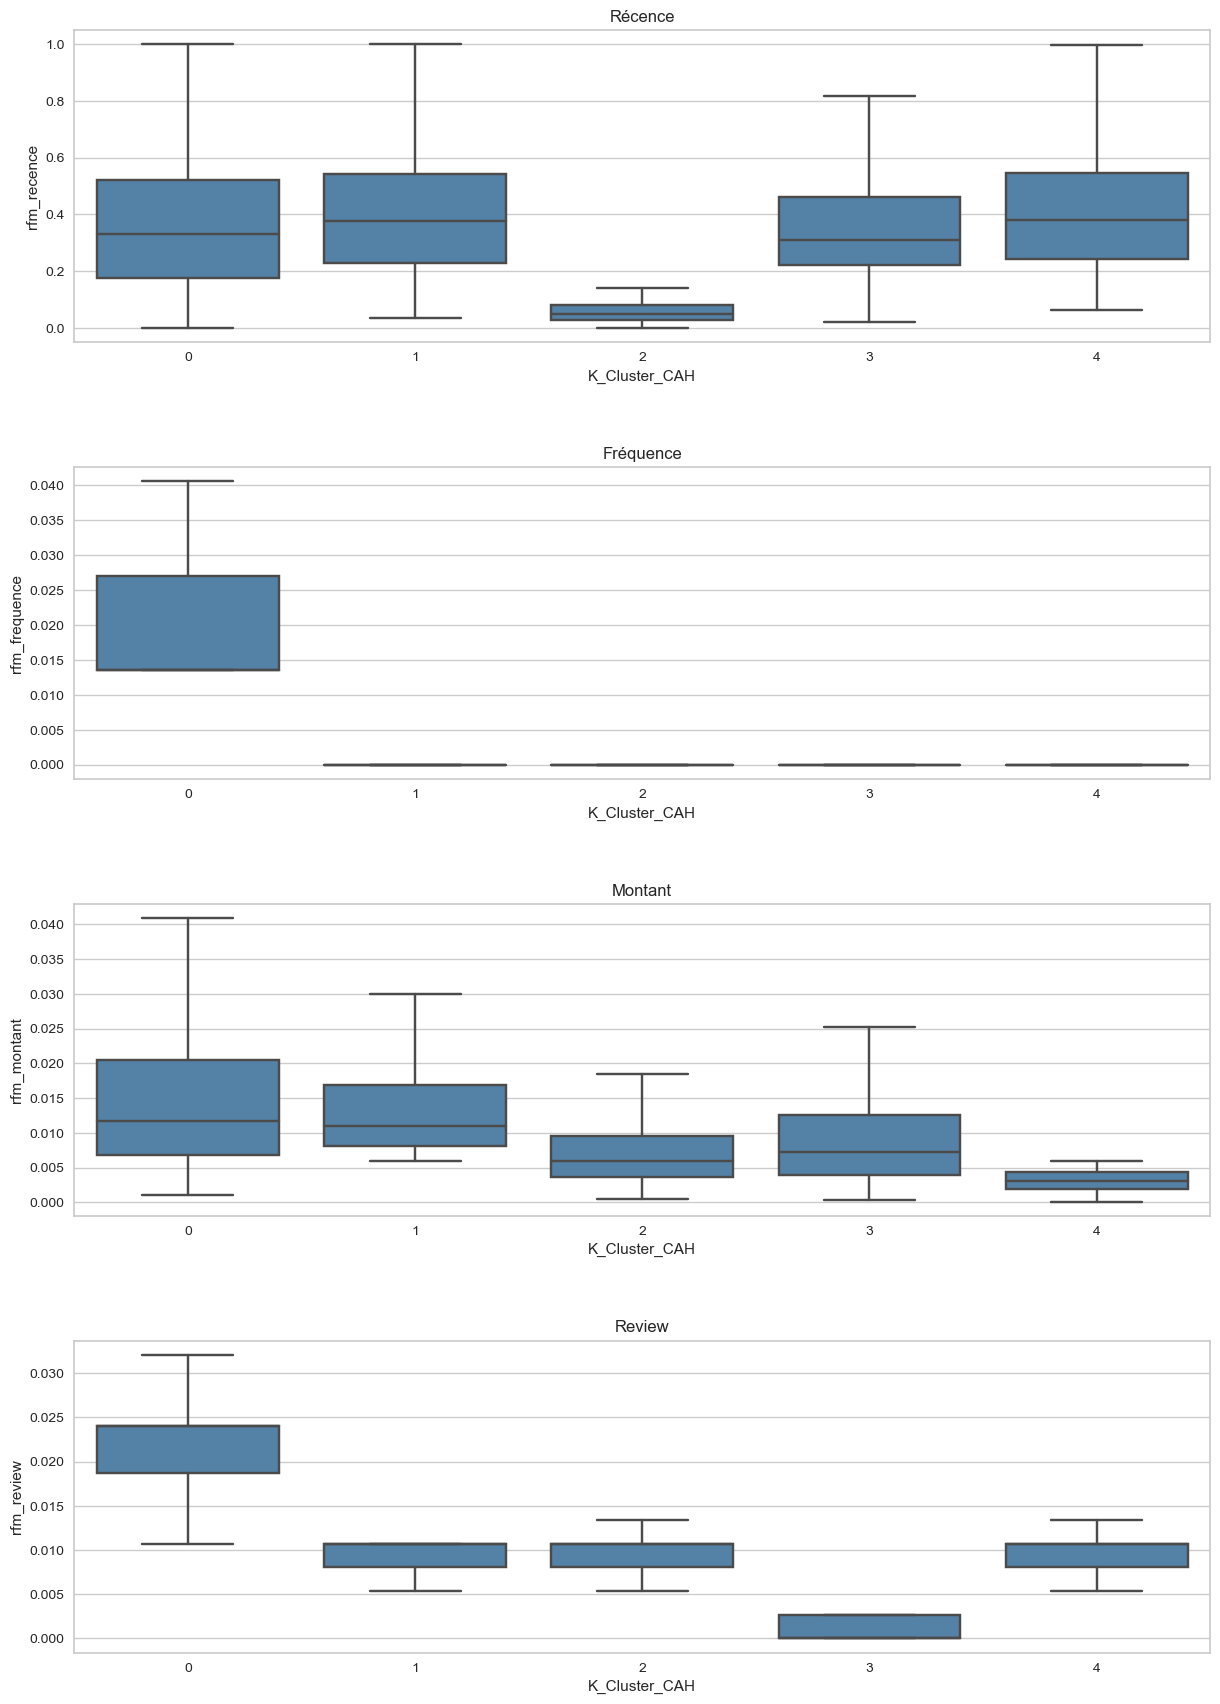

In [150]:
# Boîte à moustache des types de client
# --------------------------------------------------------------------
fig, axs = plt.subplots(4, 1)
fig.subplots_adjust(left=0.08, right=1.5, bottom=0.05,
                    top=3, hspace=0.4, wspace=0.3)

# Boxplot Récence
sns.boxplot(x='K_Cluster_CAH', y='rfm_recence', data=df_reduit_CAH,
            color='SteelBlue', ax=axs[0],showfliers=False)
axs[0].set_title('Récence')

# Boxplot Fréquence
sns.boxplot(x='K_Cluster_CAH', y='rfm_frequence', data=df_reduit_CAH,
            color='SteelBlue', ax=axs[1],showfliers=False)
axs[1].set_title('Fréquence')

# Boxplot Montant
sns.boxplot(x='K_Cluster_CAH', y='rfm_montant', data=df_reduit_CAH,
            color='SteelBlue', ax=axs[2],showfliers=False)
axs[2].set_title('Montant')
# Boxplot Review
sns.boxplot(x='K_Cluster_CAH', y='rfm_review', data=df_reduit_CAH,
            color='SteelBlue', ax=axs[3],showfliers=False)
axs[3].set_title('Review')

plt.show()